<a href="https://colab.research.google.com/github/YashviGupta15/ai-ml-notes/blob/main/Multi_Head_Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## SECTION 1: Why One Attention Head Is Not Enough

In the previous lecture, we studied scaled dot-product self-attention:

$$
\mathrm{Attention}(Q,K,V)
=
\mathrm{softmax}
\left(
\frac{QK^\top}{\sqrt{d_k}}
\right)V
$$

A single attention head allows every token to look at every other token and create a contextual representation.

However, one attention head gives only **one type of relationship pattern** between tokens.

For example, in the sentence:

$$
\text{"The movie was not good"}
$$

the word `"good"` may need to attend strongly to `"not"` because `"not good"` changes the sentiment.

But at the same time, the model may also need to understand:

- which word describes the object,
- which words form the sentiment phrase,
- which token acts as a negation,
- how nearby words relate syntactically,
- how distant words affect meaning.

A single attention head compresses all these relationships into one attention matrix.

That is useful, but limited.

Multi-head attention solves this by allowing the model to learn **multiple attention patterns in parallel**.

Each head can focus on a different type of relationship.

## Mathematics: Single Attention Head as One Relationship View

Let the input sentence contain $n$ tokens.

Let the embedding dimension be $d_{\text{model}}$.

The input embedding matrix is:

$$
X \in \mathbb{R}^{n \times d_{\text{model}}}
$$

For a single attention head, we compute:

$$
Q = XW_Q
$$

$$
K = XW_K
$$

$$
V = XW_V
$$

where:

$$
W_Q, W_K, W_V \in \mathbb{R}^{d_{\text{model}} \times d_k}
$$

The attention score matrix is:

$$
S = QK^\top
$$

Shape-wise:

$$
Q \in \mathbb{R}^{n \times d_k}
$$

$$
K^\top \in \mathbb{R}^{d_k \times n}
$$

Therefore:

$$
S = QK^\top \in \mathbb{R}^{n \times n}
$$

After scaling and softmax:

$$
A =
\mathrm{softmax}
\left(
\frac{S}{\sqrt{d_k}}
\right)
$$

where:

$$
A \in \mathbb{R}^{n \times n}
$$

Finally:

$$
Z = AV
$$

where:

$$
Z \in \mathbb{R}^{n \times d_k}
$$

The matrix $A$ tells us how each token attends to every other token.

But in a single-head setup, there is only one such matrix:

$$
A^{(1)} \in \mathbb{R}^{n \times n}
$$

So the model learns only one attention pattern at a time.

Tokens:
['The', 'movie', 'was', 'not', 'good']

Input embedding matrix X:
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024 -1.72491783 -0.56228753]
 [-1.01283112  0.31424733 -0.90802408 -1.4123037 ]]

Shape of X:
(5, 4)

Shape of W_Q: (4, 2)
Shape of W_K: (4, 2)
Shape of W_V: (4, 2)

Shape of Q: (5, 2)
Shape of K: (5, 2)
Shape of V: (5, 2)

Shape of raw attention scores QK^T: (5, 5)
Shape of scaled scores: (5, 5)
Shape of attention weight matrix A: (5, 5)
Shape of single-head output Z_single: (5, 2)

Attention weight matrix A:
[[4.43176480e-03 5.00045665e-03 2.60678903e-01 1.80179353e-02
  7.11870940e-01]
 [1.13526898e-03 1.36991930e-03 2.15971527e-01 6.82648404e-03
  7.74696801e-01]
 [4.25513994e-01 4.27173048e-01 1.43252007e-02 1.27104874e-01
  5.88288240e-03]
 [2.37841176e-04 1.90932984e-04 1.42836456e-01 2.52579232e-03
  8.54208978e-01]
 [4.44015222e-01 

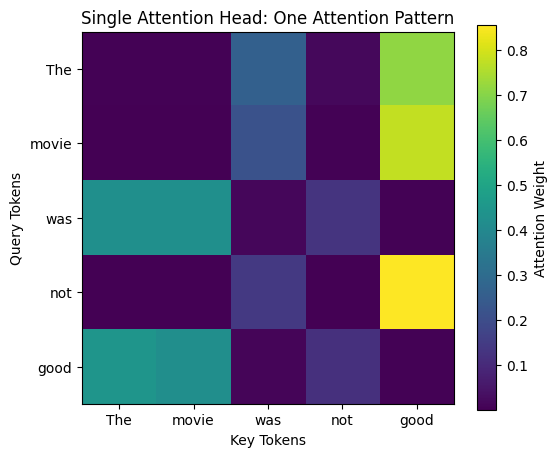

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -------------------------------
# Helper functions
# -------------------------------

def softmax(x):
    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

def row_softmax(matrix):
    matrix = matrix - np.max(matrix, axis=1, keepdims=True)
    exp_matrix = np.exp(matrix)
    return exp_matrix / np.sum(exp_matrix, axis=1, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T
    scaled_scores = scores / np.sqrt(d_k)
    attention_weights = row_softmax(scaled_scores)
    output = attention_weights @ V
    return scores, scaled_scores, attention_weights, output


# -------------------------------
# Toy sentence
# -------------------------------

tokens = ["The", "movie", "was", "not", "good"]

n = 5
d_model = 4
d_k = 2

# Toy embedding matrix
X = np.random.randn(n, d_model)

print("Tokens:")
print(tokens)

print("\nInput embedding matrix X:")
print(X)

print("\nShape of X:")
print(X.shape)


# -------------------------------
# Single-head projection matrices
# -------------------------------

W_Q = np.random.randn(d_model, d_k)
W_K = np.random.randn(d_model, d_k)
W_V = np.random.randn(d_model, d_k)

print("\nShape of W_Q:", W_Q.shape)
print("Shape of W_K:", W_K.shape)
print("Shape of W_V:", W_V.shape)


# -------------------------------
# Compute Q, K, V
# -------------------------------

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

print("\nShape of Q:", Q.shape)
print("Shape of K:", K.shape)
print("Shape of V:", V.shape)


# -------------------------------
# Single-head attention
# -------------------------------

scores, scaled_scores, attention_weights, Z_single = scaled_dot_product_attention(Q, K, V)

print("\nShape of raw attention scores QK^T:", scores.shape)
print("Shape of scaled scores:", scaled_scores.shape)
print("Shape of attention weight matrix A:", attention_weights.shape)
print("Shape of single-head output Z_single:", Z_single.shape)

print("\nAttention weight matrix A:")
print(attention_weights)


# -------------------------------
# Visualization
# -------------------------------

plt.figure(figsize=(6, 5))
plt.imshow(attention_weights)
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("Single Attention Head: One Attention Pattern")
plt.colorbar(label="Attention Weight")
plt.show()

## Observation / Interpretation

The input matrix has shape:

$$
X \in \mathbb{R}^{5 \times 4}
$$

This means we have:

$$
5 \text{ tokens}
$$

and each token is represented using:

$$
4 \text{ embedding features}
$$

For the single attention head, we projected the input into:

$$
Q, K, V \in \mathbb{R}^{5 \times 2}
$$

The attention score matrix has shape:

$$
QK^\top \in \mathbb{R}^{5 \times 5}
$$

This matrix compares every token with every other token.

The attention weight matrix also has shape:

$$
A \in \mathbb{R}^{5 \times 5}
$$

Each row of $A$ represents one token asking:

> “How much should I attend to every token in the sentence?”

For example, the row corresponding to `"good"` tells us how much `"good"` attends to:

$$
\text{"The", "movie", "was", "not", "good"}
$$

But the important limitation is this:

A single attention head produces only one attention matrix.

So it can learn only one dominant relationship pattern.

In real language, one sentence may contain multiple simultaneous relationships:

- negation relationship,
- subject-object relationship,
- adjective-noun relationship,
- syntactic dependency,
- semantic dependency,
- positional relationship.

A single head may struggle to represent all of these views cleanly.

This motivates multi-head attention.

## Concept Check

1. What is the shape of the input embedding matrix $X$ in this example?

2. Why does the attention score matrix $QK^\top$ have shape $5 \times 5$?

3. What does one row of the attention weight matrix $A$ represent?

4. Why is a single attention head limited?

5. In the sentence `"The movie was not good"`, why might the token `"good"` need to attend to `"not"`?

## Bridge to Next Section

We have now seen that a single attention head gives one attention matrix:

$$
A \in \mathbb{R}^{n \times n}
$$

This means the model gets only one view of token relationships.

But language usually requires many views at the same time.

So the next idea is simple but powerful:

Instead of computing attention once, compute it multiple times in parallel.

Each attention mechanism is called a head.

This leads us to:

$$
\text{Multi-Head Attention}
$$

## SECTION 2: Multi-Head Attention Big Picture

In the previous section, we saw that a single attention head gives only one attention pattern.

Multi-head attention extends this idea by computing several attention mechanisms in parallel.

Instead of asking:

> “What is the single best way tokens should attend to each other?”

multi-head attention asks:

> “Can different heads learn different kinds of token relationships at the same time?”

For the sentence:

$$
\text{"The movie was not good"}
$$

one head may focus on the negation relationship:

$$
\text{"not"} \rightarrow \text{"good"}
$$

another head may focus on the phrase structure:

$$
\text{"movie"} \rightarrow \text{"good"}
$$

another head may focus on nearby token dependencies.

Each head receives the same input matrix $X$, but each head uses its own projection matrices.

So every head learns its own version of:

$$
Q, K, V
$$

This allows different heads to look at the same sentence from different representation spaces.

## Mathematics: Multi-Head Attention as Parallel Self-Attention

Let the input embedding matrix be:

$$
X \in \mathbb{R}^{n \times d_{\text{model}}}
$$

In our toy example:

$$
n = 5
$$

$$
d_{\text{model}} = 4
$$

So:

$$
X \in \mathbb{R}^{5 \times 4}
$$

Suppose we use:

$$
h = 2
$$

attention heads.

Each head has its own projection matrices.

For head $1$:

$$
W_Q^{(1)}, W_K^{(1)}, W_V^{(1)} \in \mathbb{R}^{4 \times 2}
$$

For head $2$:

$$
W_Q^{(2)}, W_K^{(2)}, W_V^{(2)} \in \mathbb{R}^{4 \times 2}
$$

Each head computes its own:

$$
Q^{(r)} = XW_Q^{(r)}
$$

$$
K^{(r)} = XW_K^{(r)}
$$

$$
V^{(r)} = XW_V^{(r)}
$$

where $r$ is the head index.

For each head:

$$
Q^{(r)}, K^{(r)}, V^{(r)} \in \mathbb{R}^{5 \times 2}
$$

Then each head computes attention independently:

$$
\text{head}_r
=
\mathrm{Attention}
\left(
Q^{(r)}, K^{(r)}, V^{(r)}
\right)
$$

where:

$$
\text{head}_r \in \mathbb{R}^{5 \times 2}
$$

So with two heads, we obtain:

$$
\text{head}_1 \in \mathbb{R}^{5 \times 2}
$$

$$
\text{head}_2 \in \mathbb{R}^{5 \times 2}
$$

These heads will later be concatenated to recover a richer representation.

Tokens:
['The', 'movie', 'was', 'not', 'good']

Shape of input X:
(5, 4)

Head 1 projection shapes:
W_Q_1: (4, 2)
W_K_1: (4, 2)
W_V_1: (4, 2)

Head 2 projection shapes:
W_Q_2: (4, 2)
W_K_2: (4, 2)
W_V_2: (4, 2)

Head 1 shapes:
Q_1: (5, 2)
K_1: (5, 2)
V_1: (5, 2)

Head 2 shapes:
Q_2: (5, 2)
K_2: (5, 2)
V_2: (5, 2)

Attention output shapes:
Head 1 output: (5, 2)
Head 2 output: (5, 2)

Attention matrix shapes:
A_1: (5, 5)
A_2: (5, 5)


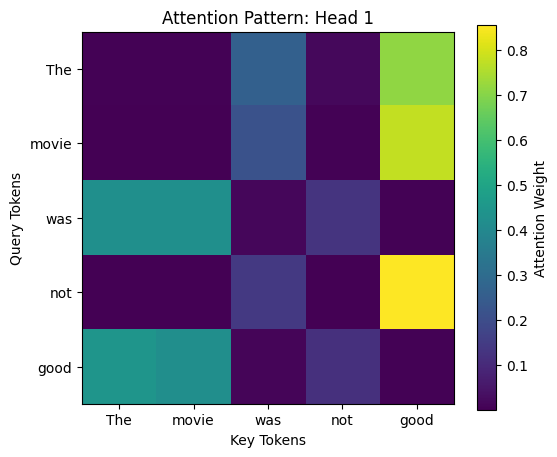

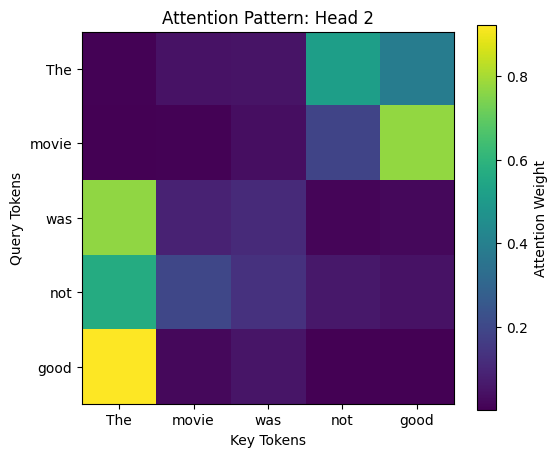

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -------------------------------
# Helper functions
# -------------------------------

def row_softmax(matrix):
    matrix = matrix - np.max(matrix, axis=1, keepdims=True)
    exp_matrix = np.exp(matrix)
    return exp_matrix / np.sum(exp_matrix, axis=1, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T
    scaled_scores = scores / np.sqrt(d_k)
    attention_weights = row_softmax(scaled_scores)
    output = attention_weights @ V
    return scores, scaled_scores, attention_weights, output


# -------------------------------
# Toy sentence and embeddings
# -------------------------------

tokens = ["The", "movie", "was", "not", "good"]

n = 5
d_model = 4
h = 2
d_k = 2

X = np.random.randn(n, d_model)

print("Tokens:")
print(tokens)

print("\nShape of input X:")
print(X.shape)


# -------------------------------
# Projection matrices for Head 1
# -------------------------------

W_Q_1 = np.random.randn(d_model, d_k)
W_K_1 = np.random.randn(d_model, d_k)
W_V_1 = np.random.randn(d_model, d_k)

print("\nHead 1 projection shapes:")
print("W_Q_1:", W_Q_1.shape)
print("W_K_1:", W_K_1.shape)
print("W_V_1:", W_V_1.shape)


# -------------------------------
# Projection matrices for Head 2
# -------------------------------

W_Q_2 = np.random.randn(d_model, d_k)
W_K_2 = np.random.randn(d_model, d_k)
W_V_2 = np.random.randn(d_model, d_k)

print("\nHead 2 projection shapes:")
print("W_Q_2:", W_Q_2.shape)
print("W_K_2:", W_K_2.shape)
print("W_V_2:", W_V_2.shape)


# -------------------------------
# Compute Q, K, V for Head 1
# -------------------------------

Q_1 = X @ W_Q_1
K_1 = X @ W_K_1
V_1 = X @ W_V_1

print("\nHead 1 shapes:")
print("Q_1:", Q_1.shape)
print("K_1:", K_1.shape)
print("V_1:", V_1.shape)


# -------------------------------
# Compute Q, K, V for Head 2
# -------------------------------

Q_2 = X @ W_Q_2
K_2 = X @ W_K_2
V_2 = X @ W_V_2

print("\nHead 2 shapes:")
print("Q_2:", Q_2.shape)
print("K_2:", K_2.shape)
print("V_2:", V_2.shape)


# -------------------------------
# Attention for each head
# -------------------------------

scores_1, scaled_scores_1, A_1, head_1 = scaled_dot_product_attention(Q_1, K_1, V_1)
scores_2, scaled_scores_2, A_2, head_2 = scaled_dot_product_attention(Q_2, K_2, V_2)

print("\nAttention output shapes:")
print("Head 1 output:", head_1.shape)
print("Head 2 output:", head_2.shape)

print("\nAttention matrix shapes:")
print("A_1:", A_1.shape)
print("A_2:", A_2.shape)


# -------------------------------
# Visualize both attention heads
# -------------------------------

plt.figure(figsize=(6, 5))
plt.imshow(A_1)
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("Attention Pattern: Head 1")
plt.colorbar(label="Attention Weight")
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(A_2)
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("Attention Pattern: Head 2")
plt.colorbar(label="Attention Weight")
plt.show()

## Observation / Interpretation

We used the same input matrix:

$$
X \in \mathbb{R}^{5 \times 4}
$$

for both attention heads.

However, Head 1 and Head 2 used different projection matrices.

For Head 1:

$$
W_Q^{(1)}, W_K^{(1)}, W_V^{(1)} \in \mathbb{R}^{4 \times 2}
$$

For Head 2:

$$
W_Q^{(2)}, W_K^{(2)}, W_V^{(2)} \in \mathbb{R}^{4 \times 2}
$$

Therefore, each head produced its own:

$$
Q^{(r)}, K^{(r)}, V^{(r)} \in \mathbb{R}^{5 \times 2}
$$

Each head also produced its own attention matrix:

$$
A^{(1)} \in \mathbb{R}^{5 \times 5}
$$

$$
A^{(2)} \in \mathbb{R}^{5 \times 5}
$$

The two heatmaps may look different because the two heads project the same input into different representation spaces.

This is the key idea.

Multi-head attention does not simply duplicate the same attention mechanism.

It gives each head separate learnable parameters, allowing each head to learn a different relational pattern.

## Concept Check

1. Why do Head 1 and Head 2 receive the same input matrix $X$?

2. If both heads receive the same $X$, why can their attention matrices be different?

3. What is the shape of $Q^{(1)}$ in this example?

4. What is the shape of the attention matrix $A^{(2)}$?

5. In simple words, what does multi-head attention allow the model to do?

## Instructor-Only Answers

1. Both heads receive the same input matrix $X$ because multi-head attention processes the same sequence through multiple parallel attention mechanisms.

2. Their attention matrices can be different because each head has different projection matrices:

$$
W_Q^{(r)}, W_K^{(r)}, W_V^{(r)}
$$

So each head creates a different representation space before computing attention.

3. In this example:

$$
Q^{(1)} \in \mathbb{R}^{5 \times 2}
$$

because:

$$
X \in \mathbb{R}^{5 \times 4}
$$

and:

$$
W_Q^{(1)} \in \mathbb{R}^{4 \times 2}
$$

Therefore:

$$
XW_Q^{(1)} \in \mathbb{R}^{5 \times 2}
$$

4. The shape of $A^{(2)}$ is:

$$
A^{(2)} \in \mathbb{R}^{5 \times 5}
$$

because every query token compares itself with every key token.

5. Multi-head attention allows the model to learn multiple token relationship patterns in parallel.

Different heads can specialize in different types of relationships, such as negation, phrase structure, syntax, or semantic relevance.

## Bridge to Next Section

We now understand the big picture:

Multi-head attention computes several attention heads in parallel.

Each head uses separate projection matrices:

$$
W_Q^{(r)}, W_K^{(r)}, W_V^{(r)}
$$

But we have not yet carefully studied why these separate projection matrices are necessary.

In the next section, we will focus specifically on:

$$
\text{Separate Projection Matrices for Each Head}
$$

This will help us understand how each head learns a different representation space.

## SECTION 3: Separate Projection Matrices for Each Head

In multi-head attention, every head receives the same input matrix:

$$
X
$$

But each head should not see the input in exactly the same way.

If all heads used the same projection matrices, then all heads would produce similar attention patterns.

That would defeat the purpose of having multiple heads.

Therefore, each head gets its own learnable projection matrices:

$$
W_Q^{(r)}, W_K^{(r)}, W_V^{(r)}
$$

where $r$ denotes the head number.

These matrices transform the same input $X$ into different query, key, and value spaces.

This means each head can learn a different way of asking:

> “Which tokens are important for this token?”

For example, one head may learn to detect negation.

Another head may learn phrase-level meaning.

Another head may learn syntactic dependency.

So the projection matrices are not just technical details.

They are the reason different heads can specialize.

## Mathematics: Head-Specific Projection Spaces

Let:

$$
X \in \mathbb{R}^{n \times d_{\text{model}}}
$$

For multi-head attention with $h$ heads, each head $r$ has separate projection matrices:

$$
W_Q^{(r)} \in \mathbb{R}^{d_{\text{model}} \times d_k}
$$

$$
W_K^{(r)} \in \mathbb{R}^{d_{\text{model}} \times d_k}
$$

$$
W_V^{(r)} \in \mathbb{R}^{d_{\text{model}} \times d_k}
$$

For head $r$, we compute:

$$
Q^{(r)} = XW_Q^{(r)}
$$

$$
K^{(r)} = XW_K^{(r)}
$$

$$
V^{(r)} = XW_V^{(r)}
$$

In our toy example:

$$
X \in \mathbb{R}^{5 \times 4}
$$

and:

$$
W_Q^{(r)}, W_K^{(r)}, W_V^{(r)} \in \mathbb{R}^{4 \times 2}
$$

Therefore:

$$
Q^{(r)}, K^{(r)}, V^{(r)} \in \mathbb{R}^{5 \times 2}
$$

For $h = 2$, we have:

$$
Q^{(1)} = XW_Q^{(1)}
$$

$$
Q^{(2)} = XW_Q^{(2)}
$$

Since:

$$
W_Q^{(1)} \neq W_Q^{(2)}
$$

we usually get:

$$
Q^{(1)} \neq Q^{(2)}
$$

Similarly:

$$
K^{(1)} \neq K^{(2)}
$$

and:

$$
V^{(1)} \neq V^{(2)}
$$

So each head computes attention in a different learned representation space.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -------------------------------
# Toy sentence and embeddings
# -------------------------------

tokens = ["The", "movie", "was", "not", "good"]

n = 5
d_model = 4
h = 2
d_k = 2

X = np.random.randn(n, d_model)

print("Tokens:")
print(tokens)

print("\nInput embedding matrix X:")
print(X)

print("\nShape of X:", X.shape)


# -------------------------------
# Separate projection matrices
# -------------------------------

W_Q_1 = np.random.randn(d_model, d_k)
W_K_1 = np.random.randn(d_model, d_k)
W_V_1 = np.random.randn(d_model, d_k)

W_Q_2 = np.random.randn(d_model, d_k)
W_K_2 = np.random.randn(d_model, d_k)
W_V_2 = np.random.randn(d_model, d_k)

print("\nHead 1 projection matrix shapes:")
print("W_Q_1:", W_Q_1.shape)
print("W_K_1:", W_K_1.shape)
print("W_V_1:", W_V_1.shape)

print("\nHead 2 projection matrix shapes:")
print("W_Q_2:", W_Q_2.shape)
print("W_K_2:", W_K_2.shape)
print("W_V_2:", W_V_2.shape)


# -------------------------------
# Compute Q, K, V for each head
# -------------------------------

Q_1 = X @ W_Q_1
K_1 = X @ W_K_1
V_1 = X @ W_V_1

Q_2 = X @ W_Q_2
K_2 = X @ W_K_2
V_2 = X @ W_V_2

print("\nHead 1 projected matrices:")
print("Q_1 shape:", Q_1.shape)
print("K_1 shape:", K_1.shape)
print("V_1 shape:", V_1.shape)

print("\nHead 2 projected matrices:")
print("Q_2 shape:", Q_2.shape)
print("K_2 shape:", K_2.shape)
print("V_2 shape:", V_2.shape)


# -------------------------------
# Compare Q matrices from both heads
# -------------------------------

print("\nQ_1:")
print(Q_1)

print("\nQ_2:")
print(Q_2)

print("\nAre Q_1 and Q_2 exactly equal?")
print(np.allclose(Q_1, Q_2))


# -------------------------------
# Compare K matrices from both heads
# -------------------------------

print("\nAre K_1 and K_2 exactly equal?")
print(np.allclose(K_1, K_2))


# -------------------------------
# Compare V matrices from both heads
# -------------------------------

print("\nAre V_1 and V_2 exactly equal?")
print(np.allclose(V_1, V_2))

Tokens:
['The', 'movie', 'was', 'not', 'good']

Input embedding matrix X:
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024 -1.72491783 -0.56228753]
 [-1.01283112  0.31424733 -0.90802408 -1.4123037 ]]

Shape of X: (5, 4)

Head 1 projection matrix shapes:
W_Q_1: (4, 2)
W_K_1: (4, 2)
W_V_1: (4, 2)

Head 2 projection matrix shapes:
W_Q_2: (4, 2)
W_K_2: (4, 2)
W_V_2: (4, 2)

Head 1 projected matrices:
Q_1 shape: (5, 2)
K_1 shape: (5, 2)
V_1 shape: (5, 2)

Head 2 projected matrices:
Q_2 shape: (5, 2)
K_2 shape: (5, 2)
V_2 shape: (5, 2)

Q_1:
[[-1.38691629  0.72888812]
 [-2.10200607  0.84994657]
 [ 0.13688209 -0.89339248]
 [ 1.81163613  2.26873055]
 [ 0.65663098 -0.85037014]]

Q_2:
[[ 0.04543429 -2.23211178]
 [ 1.24541317 -3.15869855]
 [ 0.13402967  1.90786898]
 [-0.25135717  1.06088016]
 [ 0.58301991  3.20601449]]

Are Q_1 and Q_2 exactly equal?
False

Are K_1 and

## Observation / Interpretation

Both heads received the same input:

$$
X \in \mathbb{R}^{5 \times 4}
$$

But Head 1 used:

$$
W_Q^{(1)}, W_K^{(1)}, W_V^{(1)}
$$

and Head 2 used:

$$
W_Q^{(2)}, W_K^{(2)}, W_V^{(2)}
$$

Because these projection matrices are different, the projected matrices are also different:

$$
Q^{(1)} \neq Q^{(2)}
$$

$$
K^{(1)} \neq K^{(2)}
$$

$$
V^{(1)} \neq V^{(2)}
$$

This is important.

The input sentence is the same, but each head transforms it into a different feature space.

Therefore, each head can produce a different attention pattern.

In simple terms:

- $W_Q^{(r)}$ controls how head $r$ forms questions.
- $W_K^{(r)}$ controls how head $r$ forms searchable token features.
- $W_V^{(r)}$ controls what information head $r$ passes forward.

So different heads can ask different questions and extract different information from the same sentence.

## Concept Check

1. Why should different heads have different projection matrices?

2. What would happen if all heads used the same $W_Q$, $W_K$, and $W_V$?

3. What is the shape of $W_Q^{(1)}$ in this example?

4. What is the shape of $Q^{(2)}$ in this example?

5. In simple language, what role does $W_V^{(r)}$ play?

## Instructor-Only Answers

1. Different heads should have different projection matrices so that they can transform the same input into different representation spaces.

This allows each head to learn a different attention pattern.

2. If all heads used the same $W_Q$, $W_K$, and $W_V$, then all heads would produce the same or highly similar $Q$, $K$, and $V$ matrices.

As a result, the heads would not provide much additional representational power.

3. In this example:

$$
W_Q^{(1)} \in \mathbb{R}^{4 \times 2}
$$

because:

$$
d_{\text{model}} = 4
$$

and:

$$
d_k = 2
$$

4. The shape of $Q^{(2)}$ is:

$$
Q^{(2)} \in \mathbb{R}^{5 \times 2}
$$

because:

$$
X \in \mathbb{R}^{5 \times 4}
$$

and:

$$
W_Q^{(2)} \in \mathbb{R}^{4 \times 2}
$$

Therefore:

$$
XW_Q^{(2)} \in \mathbb{R}^{5 \times 2}
$$

5. $W_V^{(r)}$ controls what information is extracted and passed forward by head $r$.

The values $V^{(r)}$ are the actual content vectors that get combined using the attention weights.

## Bridge to Next Section

We have now seen why each head needs its own projection matrices.

Each head computes its own:

$$
Q^{(r)}, K^{(r)}, V^{(r)}
$$

But before computing full attention for each head, we should carefully organize the shape setup.

In the next section, we will explicitly track:

$$
n
$$

$$
d_{\text{model}}
$$

$$
h
$$

$$
d_k
$$

and understand how these dimensions are chosen in multi-head attention.

## SECTION 4: Shape Setup for Multi-Head Attention

Before computing multi-head attention, we must clearly define the dimensions.

Multi-head attention is powerful, but most confusion comes from tensor shapes.

In our toy example, we use the sentence:

$$
\text{"The movie was not good"}
$$

So the number of tokens is:

$$
n = 5
$$

Each token is represented by an embedding vector of size:

$$
d_{\text{model}} = 4
$$

Therefore, the input matrix is:

$$
X \in \mathbb{R}^{5 \times 4}
$$

We will use:

$$
h = 2
$$

attention heads.

Each head will work in a smaller subspace of dimension:

$$
d_k = 2
$$

So each head produces an output of shape:

$$
5 \times 2
$$

Since we have two heads, after concatenation we get:

$$
5 \times 4
$$

This matches the original model dimension.

That is why multi-head attention often chooses:

$$
d_k = \frac{d_{\text{model}}}{h}
$$

This keeps the final concatenated representation compatible with the original embedding size.

## Mathematics: Dimension Setup

Let:

$$
n = \text{number of tokens}
$$

$$
d_{\text{model}} = \text{embedding dimension}
$$

$$
h = \text{number of attention heads}
$$

$$
d_k = \text{dimension used inside each head}
$$

In many Transformer implementations:

$$
d_k = \frac{d_{\text{model}}}{h}
$$

In our example:

$$
d_{\text{model}} = 4
$$

and:

$$
h = 2
$$

Therefore:

$$
d_k = \frac{4}{2} = 2
$$

The input matrix is:

$$
X \in \mathbb{R}^{n \times d_{\text{model}}}
$$

For our toy example:

$$
X \in \mathbb{R}^{5 \times 4}
$$

For each head $r$, the projection matrices are:

$$
W_Q^{(r)} \in \mathbb{R}^{d_{\text{model}} \times d_k}
$$

$$
W_K^{(r)} \in \mathbb{R}^{d_{\text{model}} \times d_k}
$$

$$
W_V^{(r)} \in \mathbb{R}^{d_{\text{model}} \times d_k}
$$

So in our example:

$$
W_Q^{(r)}, W_K^{(r)}, W_V^{(r)} \in \mathbb{R}^{4 \times 2}
$$

Then:

$$
Q^{(r)} = XW_Q^{(r)}
$$

$$
K^{(r)} = XW_K^{(r)}
$$

$$
V^{(r)} = XW_V^{(r)}
$$

Shape-wise:

$$
(5 \times 4)(4 \times 2) = 5 \times 2
$$

Therefore:

$$
Q^{(r)}, K^{(r)}, V^{(r)} \in \mathbb{R}^{5 \times 2}
$$

Each attention head output is:

$$
\text{head}_r \in \mathbb{R}^{5 \times 2}
$$

After concatenating two heads:

$$
H = \mathrm{Concat}(\text{head}_1, \text{head}_2)
$$

$$
H \in \mathbb{R}^{5 \times 4}
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -------------------------------
# Toy sentence
# -------------------------------

tokens = ["The", "movie", "was", "not", "good"]

# -------------------------------
# Shape setup
# -------------------------------

n = 5
d_model = 4
h = 2
d_k = d_model // h

print("Tokens:")
print(tokens)

print("\nNumber of tokens, n:", n)
print("Model dimension, d_model:", d_model)
print("Number of heads, h:", h)
print("Dimension per head, d_k:", d_k)


# -------------------------------
# Input embedding matrix
# -------------------------------

X = np.random.randn(n, d_model)

print("\nInput matrix X:")
print(X)

print("\nShape of X:")
print(X.shape)


# -------------------------------
# Create projection matrices for each head
# -------------------------------

W_Q = []
W_K = []
W_V = []

for head_index in range(h):
    W_Q.append(np.random.randn(d_model, d_k))
    W_K.append(np.random.randn(d_model, d_k))
    W_V.append(np.random.randn(d_model, d_k))

print("\nProjection matrix shapes for each head:")

for head_index in range(h):
    print(f"\nHead {head_index + 1}")
    print("W_Q shape:", W_Q[head_index].shape)
    print("W_K shape:", W_K[head_index].shape)
    print("W_V shape:", W_V[head_index].shape)


# -------------------------------
# Verify Q, K, V shape for each head
# -------------------------------

for head_index in range(h):
    Q = X @ W_Q[head_index]
    K = X @ W_K[head_index]
    V = X @ W_V[head_index]

    print(f"\nHead {head_index + 1} projected shapes:")
    print("Q shape:", Q.shape)
    print("K shape:", K.shape)
    print("V shape:", V.shape)


# -------------------------------
# Expected concatenated output shape
# -------------------------------

expected_concat_dim = h * d_k

print("\nExpected concatenated feature dimension:")
print("h * d_k =", expected_concat_dim)

print("\nExpected concatenated output shape:")
print((n, expected_concat_dim))

Tokens:
['The', 'movie', 'was', 'not', 'good']

Number of tokens, n: 5
Model dimension, d_model: 4
Number of heads, h: 2
Dimension per head, d_k: 2

Input matrix X:
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024 -1.72491783 -0.56228753]
 [-1.01283112  0.31424733 -0.90802408 -1.4123037 ]]

Shape of X:
(5, 4)

Projection matrix shapes for each head:

Head 1
W_Q shape: (4, 2)
W_K shape: (4, 2)
W_V shape: (4, 2)

Head 2
W_Q shape: (4, 2)
W_K shape: (4, 2)
W_V shape: (4, 2)

Head 1 projected shapes:
Q shape: (5, 2)
K shape: (5, 2)
V shape: (5, 2)

Head 2 projected shapes:
Q shape: (5, 2)
K shape: (5, 2)
V shape: (5, 2)

Expected concatenated feature dimension:
h * d_k = 4

Expected concatenated output shape:
(5, 4)


## Observation / Interpretation

The most important shape relationship in this section is:

$$
d_k = \frac{d_{\text{model}}}{h}
$$

In our example:

$$
d_{\text{model}} = 4
$$

and:

$$
h = 2
$$

So:

$$
d_k = 2
$$

Each head receives the full input:

$$
X \in \mathbb{R}^{5 \times 4}
$$

But each head projects the input into a smaller space:

$$
Q^{(r)}, K^{(r)}, V^{(r)} \in \mathbb{R}^{5 \times 2}
$$

So each head output will also have shape:

$$
\text{head}_r \in \mathbb{R}^{5 \times 2}
$$

Since there are two heads, concatenation gives:

$$
H \in \mathbb{R}^{5 \times 4}
$$

This is important because the final multi-head output should usually preserve the model dimension:

$$
d_{\text{model}} = 4
$$

So the multi-head attention block can pass its output to the next Transformer component without changing the expected representation size.

The key intuition is:

Each head works in a smaller subspace, but together the heads recover the full model dimension.

## Concept Check

1. What does $n$ represent in the input matrix $X \in \mathbb{R}^{n \times d_{\text{model}}}$?

2. In this example, what is the value of $d_{\text{model}}$?

3. If $d_{\text{model}} = 4$ and $h = 2$, what is $d_k$?

4. What is the shape of $W_Q^{(r)}$ for each head?

5. Why do we often choose $d_k = \frac{d_{\text{model}}}{h}$?

## Instructor-Only Answers

1. $n$ represents the number of tokens in the input sequence.

In this example:

$$
n = 5
$$

because the sentence has five tokens:

$$
\text{"The", "movie", "was", "not", "good"}
$$

2. In this example:

$$
d_{\text{model}} = 4
$$

Each token is represented by a 4-dimensional embedding vector.

3. If:

$$
d_{\text{model}} = 4
$$

and:

$$
h = 2
$$

then:

$$
d_k = \frac{4}{2} = 2
$$

4. For each head:

$$
W_Q^{(r)} \in \mathbb{R}^{4 \times 2}
$$

because:

$$
d_{\text{model}} = 4
$$

and:

$$
d_k = 2
$$

5. We often choose:

$$
d_k = \frac{d_{\text{model}}}{h}
$$

so that after concatenating all heads, the final feature dimension becomes:

$$
h \cdot d_k = d_{\text{model}}
$$

This keeps the output dimension compatible with the original model dimension.

## Bridge to Next Section

We have now fixed the shape setup:

$$
X \in \mathbb{R}^{5 \times 4}
$$

$$
h = 2
$$

$$
d_k = 2
$$

For each head:

$$
W_Q^{(r)}, W_K^{(r)}, W_V^{(r)} \in \mathbb{R}^{4 \times 2}
$$

and:

$$
Q^{(r)}, K^{(r)}, V^{(r)} \in \mathbb{R}^{5 \times 2}
$$

Now we are ready to explicitly compute:

$$
Q, K, V
$$

for each attention head.

This is the next step before applying scaled dot-product attention.

## SECTION 5: Computing Q, K, V for Each Head

Now that the shape setup is fixed, we compute the query, key, and value matrices for each attention head.

The input matrix is the same for every head:

$$
X \in \mathbb{R}^{5 \times 4}
$$

But each head has its own projection matrices.

For Head 1:

$$
W_Q^{(1)}, W_K^{(1)}, W_V^{(1)}
$$

For Head 2:

$$
W_Q^{(2)}, W_K^{(2)}, W_V^{(2)}
$$

So Head 1 computes:

$$
Q^{(1)}, K^{(1)}, V^{(1)}
$$

and Head 2 computes:

$$
Q^{(2)}, K^{(2)}, V^{(2)}
$$

The important idea is this:

Each head starts from the same input sentence, but transforms it into a different representation space.

That is why different heads can later produce different attention patterns.

## Mathematics: Computing Head-Specific Q, K, V

For each head $r$, we compute:

$$
Q^{(r)} = XW_Q^{(r)}
$$

$$
K^{(r)} = XW_K^{(r)}
$$

$$
V^{(r)} = XW_V^{(r)}
$$

In our toy example:

$$
X \in \mathbb{R}^{5 \times 4}
$$

and for each head:

$$
W_Q^{(r)}, W_K^{(r)}, W_V^{(r)} \in \mathbb{R}^{4 \times 2}
$$

Therefore:

$$
Q^{(r)} = XW_Q^{(r)}
$$

has shape:

$$
(5 \times 4)(4 \times 2) = 5 \times 2
$$

Similarly:

$$
K^{(r)} \in \mathbb{R}^{5 \times 2}
$$

and:

$$
V^{(r)} \in \mathbb{R}^{5 \times 2}
$$

For $h = 2$, we get:

$$
Q^{(1)}, K^{(1)}, V^{(1)} \in \mathbb{R}^{5 \times 2}
$$

and:

$$
Q^{(2)}, K^{(2)}, V^{(2)} \in \mathbb{R}^{5 \times 2}
$$

So each head has its own query, key, and value matrices.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -------------------------------
# Toy sentence and shape setup
# -------------------------------

tokens = ["The", "movie", "was", "not", "good"]

n = 5
d_model = 4
h = 2
d_k = d_model // h

X = np.random.randn(n, d_model)

print("Tokens:")
print(tokens)

print("\nShape setup:")
print("n:", n)
print("d_model:", d_model)
print("h:", h)
print("d_k:", d_k)

print("\nInput X:")
print(X)

print("\nShape of X:", X.shape)


# -------------------------------
# Projection matrices for each head
# -------------------------------

W_Q = []
W_K = []
W_V = []

for head_index in range(h):
    W_Q.append(np.random.randn(d_model, d_k))
    W_K.append(np.random.randn(d_model, d_k))
    W_V.append(np.random.randn(d_model, d_k))

print("\nProjection matrix shapes:")

for head_index in range(h):
    print(f"\nHead {head_index + 1}")
    print("W_Q shape:", W_Q[head_index].shape)
    print("W_K shape:", W_K[head_index].shape)
    print("W_V shape:", W_V[head_index].shape)


# -------------------------------
# Compute Q, K, V for each head
# -------------------------------

Q_heads = []
K_heads = []
V_heads = []

for head_index in range(h):
    Q = X @ W_Q[head_index]
    K = X @ W_K[head_index]
    V = X @ W_V[head_index]

    Q_heads.append(Q)
    K_heads.append(K)
    V_heads.append(V)

    print(f"\nHead {head_index + 1} computed matrices:")
    print("Q shape:", Q.shape)
    print("K shape:", K.shape)
    print("V shape:", V.shape)

    print("\nQ matrix:")
    print(Q)

    print("\nK matrix:")
    print(K)

    print("\nV matrix:")
    print(V)


# -------------------------------
# Compare Head 1 and Head 2 projections
# -------------------------------

print("\nAre Q matrices of Head 1 and Head 2 equal?")
print(np.allclose(Q_heads[0], Q_heads[1]))

print("\nAre K matrices of Head 1 and Head 2 equal?")
print(np.allclose(K_heads[0], K_heads[1]))

print("\nAre V matrices of Head 1 and Head 2 equal?")
print(np.allclose(V_heads[0], V_heads[1]))

Tokens:
['The', 'movie', 'was', 'not', 'good']

Shape setup:
n: 5
d_model: 4
h: 2
d_k: 2

Input X:
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024 -1.72491783 -0.56228753]
 [-1.01283112  0.31424733 -0.90802408 -1.4123037 ]]

Shape of X: (5, 4)

Projection matrix shapes:

Head 1
W_Q shape: (4, 2)
W_K shape: (4, 2)
W_V shape: (4, 2)

Head 2
W_Q shape: (4, 2)
W_K shape: (4, 2)
W_V shape: (4, 2)

Head 1 computed matrices:
Q shape: (5, 2)
K shape: (5, 2)
V shape: (5, 2)

Q matrix:
[[-1.38691629  0.72888812]
 [-2.10200607  0.84994657]
 [ 0.13688209 -0.89339248]
 [ 1.81163613  2.26873055]
 [ 0.65663098 -0.85037014]]

K matrix:
[[ 1.02886727 -2.94544094]
 [ 0.89145787 -2.97265417]
 [-0.42130627  2.20066005]
 [ 0.56667633 -1.10357654]
 [-0.73016656  3.56213898]]

V matrix:
[[ 0.58954677 -1.34821141]
 [ 1.3395147   0.45232043]
 [-1.10703442  1.08764183]
 [ 1.38296265

## Observation / Interpretation

Each head receives the same input:

$$
X \in \mathbb{R}^{5 \times 4}
$$

But each head uses different projection matrices.

For Head 1:

$$
Q^{(1)} = XW_Q^{(1)}
$$

$$
K^{(1)} = XW_K^{(1)}
$$

$$
V^{(1)} = XW_V^{(1)}
$$

For Head 2:

$$
Q^{(2)} = XW_Q^{(2)}
$$

$$
K^{(2)} = XW_K^{(2)}
$$

$$
V^{(2)} = XW_V^{(2)}
$$

The code shows that:

$$
Q^{(1)} \neq Q^{(2)}
$$

$$
K^{(1)} \neq K^{(2)}
$$

$$
V^{(1)} \neq V^{(2)}
$$

This does not happen because the input changed.

It happens because the projection matrices changed.

So each head creates a different representation of the same sentence.

This is the foundation of multi-head attention.

Before attention is even computed, each head already sees the sentence through a different learned lens.

## Concept Check

1. What is the input matrix used by both heads?

2. Why are $Q^{(1)}$ and $Q^{(2)}$ usually different?

3. What is the shape of $V^{(1)}$ in this example?

4. What does $K^{(r)}$ represent for head $r$?

5. Why is it useful for each head to have a different value matrix $V^{(r)}$?

## Instructor-Only Answers

1. Both heads use the same input matrix:

$$
X \in \mathbb{R}^{5 \times 4}
$$

2. $Q^{(1)}$ and $Q^{(2)}$ are usually different because they are computed using different projection matrices:

$$
Q^{(1)} = XW_Q^{(1)}
$$

$$
Q^{(2)} = XW_Q^{(2)}
$$

Since:

$$
W_Q^{(1)} \neq W_Q^{(2)}
$$

we generally get:

$$
Q^{(1)} \neq Q^{(2)}
$$

3. The shape of $V^{(1)}$ is:

$$
V^{(1)} \in \mathbb{R}^{5 \times 2}
$$

4. $K^{(r)}$ represents the key vectors for head $r$.

These key vectors are used to decide how relevant each token is to each query token.

5. It is useful for each head to have a different value matrix because the value vectors contain the information that will be passed forward after attention weighting.

Different value projections allow different heads to extract different types of information from the same input.

## Bridge to Next Section

We have now computed:

$$
Q^{(r)}, K^{(r)}, V^{(r)}
$$

for each attention head.

The next step is to compute scaled dot-product attention independently for each head.

For every head, we will compute:

$$
\text{head}_r
=
\mathrm{softmax}
\left(
\frac{Q^{(r)}K^{(r)\top}}{\sqrt{d_k}}
\right)
V^{(r)}
$$

This will give us the actual output representation produced by each head.

## SECTION 6: Scaled Dot-Product Attention per Head

We have already computed separate query, key, and value matrices for each head:

$$
Q^{(r)}, K^{(r)}, V^{(r)}
$$

Now each head independently applies scaled dot-product attention.

This means Head 1 computes attention using:

$$
Q^{(1)}, K^{(1)}, V^{(1)}
$$

and Head 2 computes attention using:

$$
Q^{(2)}, K^{(2)}, V^{(2)}
$$

The heads do not share attention scores.

Each head produces its own attention matrix and its own contextual output.

So for two heads, we get:

$$
\text{head}_1
$$

and:

$$
\text{head}_2
$$

Each head output has shape:

$$
5 \times 2
$$

These outputs will later be concatenated.

## Mathematics: Attention Computation Inside Each Head

For head $r$, scaled dot-product attention is:

$$
\text{head}_r
=
\mathrm{Attention}
\left(
Q^{(r)}, K^{(r)}, V^{(r)}
\right)
$$

where:

$$
\text{head}_r
=
\mathrm{softmax}
\left(
\frac{Q^{(r)}K^{(r)\top}}{\sqrt{d_k}}
\right)
V^{(r)}
$$

First, compute the raw attention score matrix:

$$
S^{(r)} = Q^{(r)}K^{(r)\top}
$$

Shape-wise:

$$
Q^{(r)} \in \mathbb{R}^{5 \times 2}
$$

$$
K^{(r)\top} \in \mathbb{R}^{2 \times 5}
$$

Therefore:

$$
S^{(r)} \in \mathbb{R}^{5 \times 5}
$$

Then scale the scores:

$$
\tilde{S}^{(r)} = \frac{S^{(r)}}{\sqrt{d_k}}
$$

Since:

$$
d_k = 2
$$

we divide by:

$$
\sqrt{2}
$$

Then apply row-wise softmax:

$$
A^{(r)}
=
\mathrm{softmax}
\left(
\tilde{S}^{(r)}
\right)
$$

where:

$$
A^{(r)} \in \mathbb{R}^{5 \times 5}
$$

Finally, compute the head output:

$$
\text{head}_r = A^{(r)}V^{(r)}
$$

Shape-wise:

$$
(5 \times 5)(5 \times 2) = 5 \times 2
$$

Therefore:

$$
\text{head}_r \in \mathbb{R}^{5 \times 2}
$$

Tokens:
['The', 'movie', 'was', 'not', 'good']

Shape setup:
X shape: (5, 4)
n: 5
d_model: 4
h: 2
d_k: 2

Projection matrix shapes:

Head 1
W_Q shape: (4, 2)
W_K shape: (4, 2)
W_V shape: (4, 2)

Head 2
W_Q shape: (4, 2)
W_K shape: (4, 2)
W_V shape: (4, 2)

================ Head 1 ================

Q shape: (5, 2)
K shape: (5, 2)
V shape: (5, 2)

Raw score matrix S shape: (5, 5)
Scaled score matrix shape: (5, 5)
Attention matrix A shape: (5, 5)
Head output shape: (5, 2)

Attention matrix A:
[[4.43176480e-03 5.00045665e-03 2.60678903e-01 1.80179353e-02
  7.11870940e-01]
 [1.13526898e-03 1.36991930e-03 2.15971527e-01 6.82648404e-03
  7.74696801e-01]
 [4.25513994e-01 4.27173048e-01 1.43252007e-02 1.27104874e-01
  5.88288240e-03]
 [2.37841176e-04 1.90932984e-04 1.42836456e-01 2.52579232e-03
  8.54208978e-01]
 [4.44015222e-01 4.23444273e-01 1.02591297e-02 1.18361339e-01
  3.92003650e-03]]

Row sums of attention matrix:
[1. 1. 1. 1. 1.]

================ Head 2 ================

Q shape: (5, 

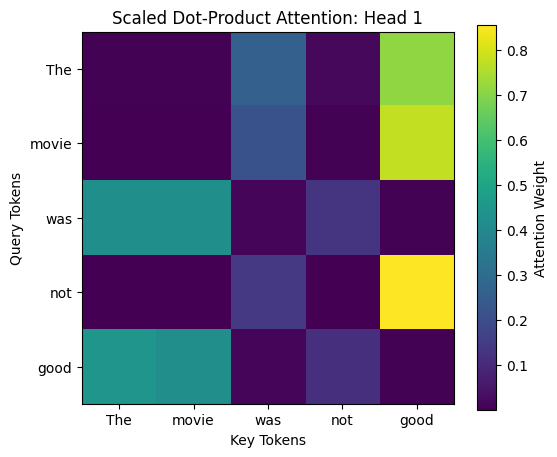

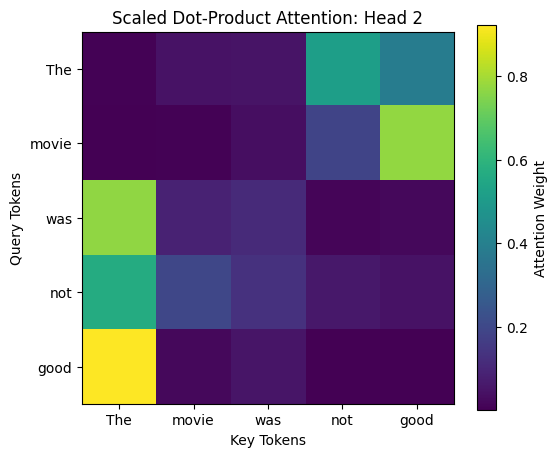

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -------------------------------
# Helper functions
# -------------------------------

def row_softmax(matrix):
    matrix = matrix - np.max(matrix, axis=1, keepdims=True)
    exp_matrix = np.exp(matrix)
    return exp_matrix / np.sum(exp_matrix, axis=1, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T
    scaled_scores = scores / np.sqrt(d_k)
    attention_weights = row_softmax(scaled_scores)
    output = attention_weights @ V
    return scores, scaled_scores, attention_weights, output


# -------------------------------
# Toy sentence and shape setup
# -------------------------------

tokens = ["The", "movie", "was", "not", "good"]

n = 5
d_model = 4
h = 2
d_k = d_model // h

X = np.random.randn(n, d_model)

print("Tokens:")
print(tokens)

print("\nShape setup:")
print("X shape:", X.shape)
print("n:", n)
print("d_model:", d_model)
print("h:", h)
print("d_k:", d_k)


# -------------------------------
# Projection matrices for each head
# -------------------------------

W_Q = []
W_K = []
W_V = []

for head_index in range(h):
    W_Q.append(np.random.randn(d_model, d_k))
    W_K.append(np.random.randn(d_model, d_k))
    W_V.append(np.random.randn(d_model, d_k))

print("\nProjection matrix shapes:")

for head_index in range(h):
    print(f"\nHead {head_index + 1}")
    print("W_Q shape:", W_Q[head_index].shape)
    print("W_K shape:", W_K[head_index].shape)
    print("W_V shape:", W_V[head_index].shape)


# -------------------------------
# Compute attention per head
# -------------------------------

attention_scores = []
scaled_attention_scores = []
attention_matrices = []
head_outputs = []

for head_index in range(h):
    Q = X @ W_Q[head_index]
    K = X @ W_K[head_index]
    V = X @ W_V[head_index]

    scores, scaled_scores, A, head_output = scaled_dot_product_attention(Q, K, V)

    attention_scores.append(scores)
    scaled_attention_scores.append(scaled_scores)
    attention_matrices.append(A)
    head_outputs.append(head_output)

    print(f"\n================ Head {head_index + 1} ================")

    print("\nQ shape:", Q.shape)
    print("K shape:", K.shape)
    print("V shape:", V.shape)

    print("\nRaw score matrix S shape:", scores.shape)
    print("Scaled score matrix shape:", scaled_scores.shape)
    print("Attention matrix A shape:", A.shape)
    print("Head output shape:", head_output.shape)

    print("\nAttention matrix A:")
    print(A)

    print("\nRow sums of attention matrix:")
    print(np.sum(A, axis=1))


# -------------------------------
# Visualize attention matrix for Head 1
# -------------------------------

plt.figure(figsize=(6, 5))
plt.imshow(attention_matrices[0])
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("Scaled Dot-Product Attention: Head 1")
plt.colorbar(label="Attention Weight")
plt.show()


# -------------------------------
# Visualize attention matrix for Head 2
# -------------------------------

plt.figure(figsize=(6, 5))
plt.imshow(attention_matrices[1])
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("Scaled Dot-Product Attention: Head 2")
plt.colorbar(label="Attention Weight")
plt.show()

## Observation / Interpretation

Each head independently computed scaled dot-product attention.

For each head, the projected matrices had shape:

$$
Q^{(r)}, K^{(r)}, V^{(r)} \in \mathbb{R}^{5 \times 2}
$$

The raw score matrix was computed as:

$$
S^{(r)} = Q^{(r)}K^{(r)\top}
$$

with shape:

$$
S^{(r)} \in \mathbb{R}^{5 \times 5}
$$

This means every query token compared itself with every key token.

After scaling and row-wise softmax, each head produced its own attention matrix:

$$
A^{(r)} \in \mathbb{R}^{5 \times 5}
$$

Each row of $A^{(r)}$ sums to $1$.

This is important because each row behaves like a probability distribution over the tokens.

Finally, each head output was computed as:

$$
\text{head}_r = A^{(r)}V^{(r)}
$$

with shape:

$$
\text{head}_r \in \mathbb{R}^{5 \times 2}
$$

The two heatmaps may show different attention patterns.

That difference is the main purpose of multi-head attention.

Each head is allowed to focus on a different relational structure in the same sentence.

## Concept Check

1. What is the formula for the output of head $r$?

2. Why does $Q^{(r)}K^{(r)\top}$ produce a $5 \times 5$ matrix?

3. Why do we divide the attention scores by $\sqrt{d_k}$?

4. What does one row of $A^{(r)}$ represent?

5. What is the shape of each head output in this example?

## Instructor-Only Answers

1. The output of head $r$ is:

$$
\text{head}_r
=
\mathrm{softmax}
\left(
\frac{Q^{(r)}K^{(r)\top}}{\sqrt{d_k}}
\right)
V^{(r)}
$$

2. We have:

$$
Q^{(r)} \in \mathbb{R}^{5 \times 2}
$$

and:

$$
K^{(r)\top} \in \mathbb{R}^{2 \times 5}
$$

Therefore:

$$
Q^{(r)}K^{(r)\top} \in \mathbb{R}^{5 \times 5}
$$

3. We divide by $\sqrt{d_k}$ to control the magnitude of dot products.

Without scaling, large dot products can make the softmax distribution too sharp.

That can cause one token to dominate too strongly and reduce useful gradient flow during training.

4. One row of $A^{(r)}$ represents how one query token distributes attention over all key tokens.

For example, the row for `"good"` tells us how much `"good"` attends to each token:

$$
\text{"The", "movie", "was", "not", "good"}
$$

5. Each head output has shape:

$$
\text{head}_r \in \mathbb{R}^{5 \times 2}
$$

because:

$$
A^{(r)} \in \mathbb{R}^{5 \times 5}
$$

and:

$$
V^{(r)} \in \mathbb{R}^{5 \times 2}
$$

so:

$$
A^{(r)}V^{(r)} \in \mathbb{R}^{5 \times 2}
$$

## Bridge to Next Section

We have now computed attention independently for each head.

Each head produced:

$$
A^{(r)} \in \mathbb{R}^{5 \times 5}
$$

and:

$$
\text{head}_r \in \mathbb{R}^{5 \times 2}
$$

The next important question is:

> Are different heads actually looking at the sentence differently?

To answer this, we will visualize attention patterns across heads more carefully.

This will help us interpret what multi-head attention is doing.

## SECTION 7: Visualizing Attention Patterns Across Heads

Multi-head attention becomes meaningful only when different heads are allowed to learn different attention patterns.

Each head receives the same input sentence:

$$
\text{"The movie was not good"}
$$

But each head uses different projection matrices.

Therefore, each head produces a different attention matrix:

$$
A^{(1)}, A^{(2)}, \dots, A^{(h)}
$$

In our toy example, we have:

$$
h = 2
$$

So we get two attention matrices:

$$
A^{(1)} \in \mathbb{R}^{5 \times 5}
$$

and:

$$
A^{(2)} \in \mathbb{R}^{5 \times 5}
$$

A heatmap helps us visually inspect these matrices.

Rows represent query tokens.

Columns represent key tokens.

A darker or stronger cell means:

> “This query token is attending more strongly to that key token.”

By comparing heatmaps across heads, we can see whether different heads are capturing different relational views of the same sentence.

Tokens:
['The', 'movie', 'was', 'not', 'good']

Shape setup:
X shape: (5, 4)
n: 5
d_model: 4
h: 2
d_k: 2

Projection matrix shapes:

Head 1
W_Q shape: (4, 2)
W_K shape: (4, 2)
W_V shape: (4, 2)

Head 2
W_Q shape: (4, 2)
W_K shape: (4, 2)
W_V shape: (4, 2)

================ Head 1 ================
Q shape: (5, 2)
K shape: (5, 2)
V shape: (5, 2)
Attention matrix shape: (5, 5)
Head output shape: (5, 2)

Attention matrix:
[[4.43176480e-03 5.00045665e-03 2.60678903e-01 1.80179353e-02
  7.11870940e-01]
 [1.13526898e-03 1.36991930e-03 2.15971527e-01 6.82648404e-03
  7.74696801e-01]
 [4.25513994e-01 4.27173048e-01 1.43252007e-02 1.27104874e-01
  5.88288240e-03]
 [2.37841176e-04 1.90932984e-04 1.42836456e-01 2.52579232e-03
  8.54208978e-01]
 [4.44015222e-01 4.23444273e-01 1.02591297e-02 1.18361339e-01
  3.92003650e-03]]

Row sums:
[1. 1. 1. 1. 1.]

================ Head 2 ================
Q shape: (5, 2)
K shape: (5, 2)
V shape: (5, 2)
Attention matrix shape: (5, 5)
Head output shape: (5, 2)

A

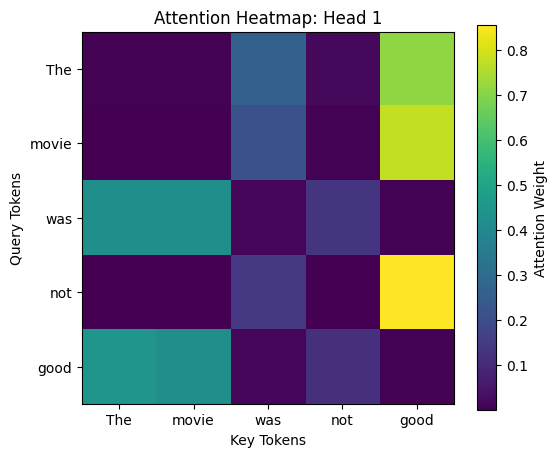

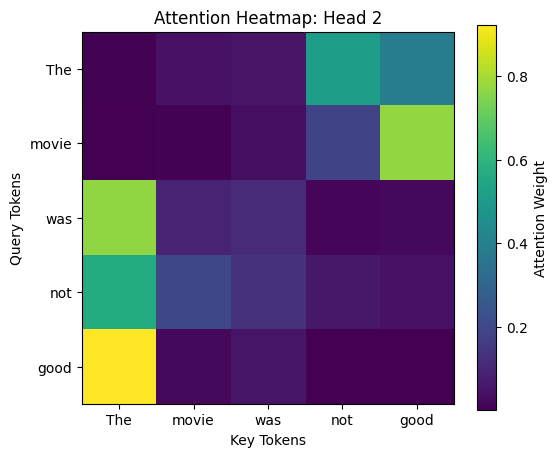

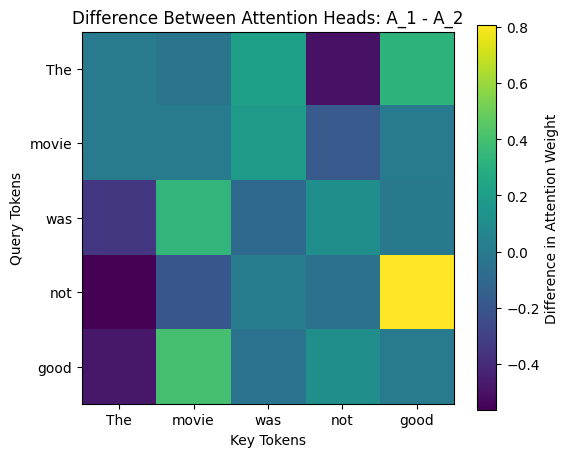

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -------------------------------
# Helper functions
# -------------------------------

def row_softmax(matrix):
    matrix = matrix - np.max(matrix, axis=1, keepdims=True)
    exp_matrix = np.exp(matrix)
    return exp_matrix / np.sum(exp_matrix, axis=1, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T
    scaled_scores = scores / np.sqrt(d_k)
    attention_weights = row_softmax(scaled_scores)
    output = attention_weights @ V
    return scores, scaled_scores, attention_weights, output


# -------------------------------
# Toy sentence and shape setup
# -------------------------------

tokens = ["The", "movie", "was", "not", "good"]

n = 5
d_model = 4
h = 2
d_k = d_model // h

X = np.random.randn(n, d_model)

print("Tokens:")
print(tokens)

print("\nShape setup:")
print("X shape:", X.shape)
print("n:", n)
print("d_model:", d_model)
print("h:", h)
print("d_k:", d_k)


# -------------------------------
# Projection matrices for each head
# -------------------------------

W_Q = []
W_K = []
W_V = []

for head_index in range(h):
    W_Q.append(np.random.randn(d_model, d_k))
    W_K.append(np.random.randn(d_model, d_k))
    W_V.append(np.random.randn(d_model, d_k))

print("\nProjection matrix shapes:")

for head_index in range(h):
    print(f"\nHead {head_index + 1}")
    print("W_Q shape:", W_Q[head_index].shape)
    print("W_K shape:", W_K[head_index].shape)
    print("W_V shape:", W_V[head_index].shape)


# -------------------------------
# Compute attention matrices
# -------------------------------

attention_matrices = []
head_outputs = []

for head_index in range(h):
    Q = X @ W_Q[head_index]
    K = X @ W_K[head_index]
    V = X @ W_V[head_index]

    scores, scaled_scores, A, head_output = scaled_dot_product_attention(Q, K, V)

    attention_matrices.append(A)
    head_outputs.append(head_output)

    print(f"\n================ Head {head_index + 1} ================")
    print("Q shape:", Q.shape)
    print("K shape:", K.shape)
    print("V shape:", V.shape)
    print("Attention matrix shape:", A.shape)
    print("Head output shape:", head_output.shape)

    print("\nAttention matrix:")
    print(A)

    print("\nRow sums:")
    print(np.sum(A, axis=1))


# -------------------------------
# Compare attention matrices
# -------------------------------

difference = attention_matrices[0] - attention_matrices[1]

print("\nShape of difference matrix A_1 - A_2:")
print(difference.shape)

print("\nDifference matrix A_1 - A_2:")
print(difference)

print("\nAre Head 1 and Head 2 attention matrices exactly equal?")
print(np.allclose(attention_matrices[0], attention_matrices[1]))


# -------------------------------
# Visualize Head 1 attention
# -------------------------------

plt.figure(figsize=(6, 5))
plt.imshow(attention_matrices[0])
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("Attention Heatmap: Head 1")
plt.colorbar(label="Attention Weight")
plt.show()


# -------------------------------
# Visualize Head 2 attention
# -------------------------------

plt.figure(figsize=(6, 5))
plt.imshow(attention_matrices[1])
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("Attention Heatmap: Head 2")
plt.colorbar(label="Attention Weight")
plt.show()


# -------------------------------
# Visualize difference between heads
# -------------------------------

plt.figure(figsize=(6, 5))
plt.imshow(difference)
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("Difference Between Attention Heads: A_1 - A_2")
plt.colorbar(label="Difference in Attention Weight")
plt.show()

## Observation / Interpretation

Each attention head produced an attention matrix of shape:

$$
A^{(r)} \in \mathbb{R}^{5 \times 5}
$$

The rows correspond to query tokens.

The columns correspond to key tokens.

So the cell:

$$
A_{ij}^{(r)}
$$

means:

> In head $r$, how much does token $i$ attend to token $j$?

For example, the row corresponding to `"good"` tells us how much `"good"` attends to:

$$
\text{"The", "movie", "was", "not", "good"}
$$

The two heatmaps may not look the same.

This happens because:

$$
W_Q^{(1)}, W_K^{(1)}, W_V^{(1)}
$$

are different from:

$$
W_Q^{(2)}, W_K^{(2)}, W_V^{(2)}
$$

So the two heads compute attention in different projected spaces.

The difference heatmap:

$$
A^{(1)} - A^{(2)}
$$

shows where the two heads assign different attention strengths.

In a trained Transformer, such differences may correspond to meaningful specialization.

For example:

- one head may focus on negation,
- one head may focus on local phrase structure,
- one head may focus on long-range dependency,
- one head may focus on punctuation or positional behavior.

In our toy NumPy example, the weights are random, so we should not over-interpret the attention patterns semantically.

The purpose here is to understand the shape flow and the mechanism.

## Concept Check

1. What does a row of an attention heatmap represent?

2. What does a column of an attention heatmap represent?

3. What does the value $A_{ij}^{(r)}$ mean?

4. Why can Head 1 and Head 2 produce different heatmaps?

5. Why should we avoid strong semantic interpretation of attention heatmaps in this toy example?

## Instructor-Only Answers

1. A row represents a query token.

It shows how that query token distributes attention over all key tokens.

2. A column represents a key token.

It shows how much different query tokens attend to that key token.

3. The value:

$$
A_{ij}^{(r)}
$$

means the attention weight from query token $i$ to key token $j$ in head $r$.

4. Head 1 and Head 2 can produce different heatmaps because they use different projection matrices:

$$
W_Q^{(1)}, W_K^{(1)}, W_V^{(1)}
$$

and:

$$
W_Q^{(2)}, W_K^{(2)}, W_V^{(2)}
$$

So they compute attention in different representation spaces.

5. We should avoid strong semantic interpretation because the projection matrices are randomly initialized.

The model has not been trained.

Therefore, the heatmaps demonstrate mechanism and shape behavior, not learned linguistic meaning.

## Bridge to Next Section

We have now seen that each head produces its own output:

$$
\text{head}_1 \in \mathbb{R}^{5 \times 2}
$$

and:

$$
\text{head}_2 \in \mathbb{R}^{5 \times 2}
$$

But the Transformer cannot pass two separate head outputs forward independently.

The outputs must be combined into one matrix.

The next step is therefore:

$$
\text{Concatenating Attention Heads}
$$

This will merge the information from all heads into a single representation.

## SECTION 8: Concatenating Attention Heads

Each attention head produces its own contextual representation.

In our example, we have two heads:

$$
\text{head}_1 \in \mathbb{R}^{5 \times 2}
$$

and:

$$
\text{head}_2 \in \mathbb{R}^{5 \times 2}
$$

Each head has captured information from a different projected attention space.

But the next layer of the model expects one combined representation, not two separate matrices.

So we concatenate the head outputs along the feature dimension.

This means we place the features from Head 1 and Head 2 side by side.

The result is:

$$
H \in \mathbb{R}^{5 \times 4}
$$

This combined matrix contains information from all heads.

Concatenation is the step where multiple attention views are merged into one representation.

## Mathematics: Concatenating Head Outputs

For two attention heads, we have:

$$
\text{head}_1 \in \mathbb{R}^{5 \times 2}
$$

and:

$$
\text{head}_2 \in \mathbb{R}^{5 \times 2}
$$

The concatenated output is:

$$
H = \mathrm{Concat}(\text{head}_1, \text{head}_2)
$$

Since concatenation happens along the feature dimension:

$$
H \in \mathbb{R}^{5 \times (2 + 2)}
$$

Therefore:

$$
H \in \mathbb{R}^{5 \times 4}
$$

More generally, for $h$ heads:

$$
\text{head}_r \in \mathbb{R}^{n \times d_k}
$$

for:

$$
r = 1, 2, \dots, h
$$

Then:

$$
H =
\mathrm{Concat}
\left(
\text{head}_1,
\text{head}_2,
\dots,
\text{head}_h
\right)
$$

and:

$$
H \in \mathbb{R}^{n \times (h d_k)}
$$

If:

$$
d_k = \frac{d_{\text{model}}}{h}
$$

then:

$$
h d_k = d_{\text{model}}
$$

So:

$$
H \in \mathbb{R}^{n \times d_{\text{model}}}
$$

In our example:

$$
h = 2
$$

$$
d_k = 2
$$

Therefore:

$$
h d_k = 2 \times 2 = 4
$$

and:

$$
H \in \mathbb{R}^{5 \times 4}
$$

Tokens:
['The', 'movie', 'was', 'not', 'good']

Shape setup:
X shape: (5, 4)
n: 5
d_model: 4
h: 2
d_k: 2

================ Head 1 ================
Q shape: (5, 2)
K shape: (5, 2)
V shape: (5, 2)
Attention matrix shape: (5, 5)
Head output shape: (5, 2)

Head output:
[[-1.06313467  1.91112855]
 [-1.10730484  2.02176526]
 [ 0.97630402 -0.47545136]
 [-1.12473459  2.13127513]
 [ 0.97685597 -0.50250718]]

================ Head 2 ================
Q shape: (5, 2)
K shape: (5, 2)
V shape: (5, 2)
Attention matrix shape: (5, 5)
Head output shape: (5, 2)

Head output:
[[ 0.17528449 -1.36668523]
 [-0.28211559 -2.35901026]
 [ 0.31525317  1.95409932]
 [ 0.42083077  1.64800912]
 [ 0.29949111  2.25755955]]

================ Concatenation ================

Head 1 output shape:
(5, 2)

Head 2 output shape:
(5, 2)

Concatenated output H_concat shape:
(5, 4)

Concatenated output H_concat:
[[-1.06313467  1.91112855  0.17528449 -1.36668523]
 [-1.10730484  2.02176526 -0.28211559 -2.35901026]
 [ 0.97630402 -0.

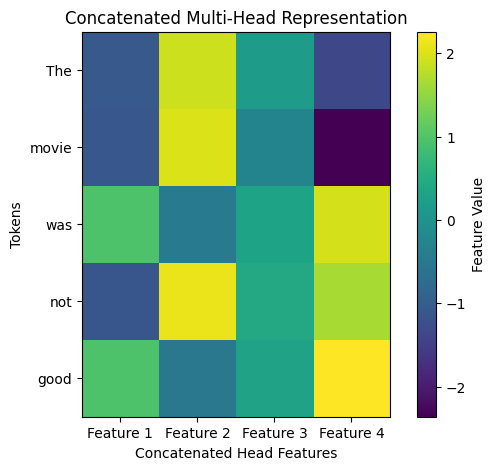

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -------------------------------
# Helper functions
# -------------------------------

def row_softmax(matrix):
    matrix = matrix - np.max(matrix, axis=1, keepdims=True)
    exp_matrix = np.exp(matrix)
    return exp_matrix / np.sum(exp_matrix, axis=1, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T
    scaled_scores = scores / np.sqrt(d_k)
    attention_weights = row_softmax(scaled_scores)
    output = attention_weights @ V
    return scores, scaled_scores, attention_weights, output


# -------------------------------
# Toy sentence and shape setup
# -------------------------------

tokens = ["The", "movie", "was", "not", "good"]

n = 5
d_model = 4
h = 2
d_k = d_model // h

X = np.random.randn(n, d_model)

print("Tokens:")
print(tokens)

print("\nShape setup:")
print("X shape:", X.shape)
print("n:", n)
print("d_model:", d_model)
print("h:", h)
print("d_k:", d_k)


# -------------------------------
# Projection matrices for each head
# -------------------------------

W_Q = []
W_K = []
W_V = []

for head_index in range(h):
    W_Q.append(np.random.randn(d_model, d_k))
    W_K.append(np.random.randn(d_model, d_k))
    W_V.append(np.random.randn(d_model, d_k))


# -------------------------------
# Compute head outputs
# -------------------------------

head_outputs = []
attention_matrices = []

for head_index in range(h):
    Q = X @ W_Q[head_index]
    K = X @ W_K[head_index]
    V = X @ W_V[head_index]

    scores, scaled_scores, A, head_output = scaled_dot_product_attention(Q, K, V)

    attention_matrices.append(A)
    head_outputs.append(head_output)

    print(f"\n================ Head {head_index + 1} ================")
    print("Q shape:", Q.shape)
    print("K shape:", K.shape)
    print("V shape:", V.shape)
    print("Attention matrix shape:", A.shape)
    print("Head output shape:", head_output.shape)

    print("\nHead output:")
    print(head_output)


# -------------------------------
# Concatenate head outputs
# -------------------------------

H_concat = np.concatenate(head_outputs, axis=1)

print("\n================ Concatenation ================")

print("\nHead 1 output shape:")
print(head_outputs[0].shape)

print("\nHead 2 output shape:")
print(head_outputs[1].shape)

print("\nConcatenated output H_concat shape:")
print(H_concat.shape)

print("\nConcatenated output H_concat:")
print(H_concat)


# -------------------------------
# Verify expected shape
# -------------------------------

expected_shape = (n, h * d_k)

print("\nExpected concatenated shape:")
print(expected_shape)

print("\nDoes H_concat have the expected shape?")
print(H_concat.shape == expected_shape)


# -------------------------------
# Visualize concatenated representation
# -------------------------------

plt.figure(figsize=(7, 5))
plt.imshow(H_concat)
plt.xticks(range(H_concat.shape[1]), [f"Feature {i+1}" for i in range(H_concat.shape[1])])
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Concatenated Head Features")
plt.ylabel("Tokens")
plt.title("Concatenated Multi-Head Representation")
plt.colorbar(label="Feature Value")
plt.show()

## Observation / Interpretation

Each head output has shape:

$$
\text{head}_r \in \mathbb{R}^{5 \times 2}
$$

For two heads, we obtained:

$$
\text{head}_1 \in \mathbb{R}^{5 \times 2}
$$

and:

$$
\text{head}_2 \in \mathbb{R}^{5 \times 2}
$$

After concatenation along the feature axis, we get:

$$
H_{\text{concat}} \in \mathbb{R}^{5 \times 4}
$$

This means each token now has a combined representation containing information from both heads.

For each token, the first two features come from Head 1 and the next two features come from Head 2.

So concatenation does not mix the heads yet.

It simply places their outputs side by side.

The mixing will happen in the next step using the output projection matrix:

$$
W_O
$$

This is why concatenation alone is not the final multi-head attention output.

## Concept Check

1. What is the shape of each head output in this example?

2. Along which axis do we concatenate the head outputs?

3. What is the shape of the concatenated matrix $H$?

4. Does concatenation itself mix information across heads?

5. Why is concatenation not the final step of multi-head attention?

## Instructor-Only Answers

1. Each head output has shape:

$$
\text{head}_r \in \mathbb{R}^{5 \times 2}
$$

2. We concatenate along the feature dimension.

In NumPy, this means:

$$
\text{axis} = 1
$$

because the shape is:

$$
(\text{tokens}, \text{features})
$$

3. The concatenated matrix has shape:

$$
H \in \mathbb{R}^{5 \times 4}
$$

because:

$$
\text{head}_1 \in \mathbb{R}^{5 \times 2}
$$

and:

$$
\text{head}_2 \in \mathbb{R}^{5 \times 2}
$$

So:

$$
\mathrm{Concat}(\text{head}_1, \text{head}_2)
\in
\mathbb{R}^{5 \times 4}
$$

4. No.

Concatenation does not mix information across heads.

It only places the outputs of different heads side by side.

5. Concatenation is not the final step because the model still needs to combine and transform information from different heads.

This is done using the output projection matrix:

$$
W_O
$$

The output projection allows the model to mix features from all heads into a final representation.

## Bridge to Next Section

We have now concatenated the outputs of multiple attention heads:

$$
H =
\mathrm{Concat}
\left(
\text{head}_1,
\text{head}_2
\right)
$$

and obtained:

$$
H \in \mathbb{R}^{5 \times 4}
$$

But concatenation only places head outputs side by side.

It does not yet learn how to combine them.

The next step is to apply the output projection matrix:

$$
W_O
$$

This gives us the final multi-head attention output.

## SECTION 9: Output Projection Matrix $W_O$

After computing attention independently in each head, we concatenate the head outputs.

For our toy example:

$$
\text{head}_1 \in \mathbb{R}^{5 \times 2}
$$

$$
\text{head}_2 \in \mathbb{R}^{5 \times 2}
$$

After concatenation:

$$
H =
\mathrm{Concat}
\left(
\text{head}_1,
\text{head}_2
\right)
$$

So:

$$
H \in \mathbb{R}^{5 \times 4}
$$

But concatenation only places the head outputs side by side.

It does not allow the model to learn how information from different heads should be combined.

This is why multi-head attention uses an output projection matrix:

$$
W_O
$$

The output projection transforms the concatenated head representation into the final multi-head attention output.

It allows the model to mix information across heads.

So the final output is:

$$
Z = HW_O
$$

In our toy example:

$$
H \in \mathbb{R}^{5 \times 4}
$$

and:

$$
W_O \in \mathbb{R}^{4 \times 4}
$$

Therefore:

$$
Z \in \mathbb{R}^{5 \times 4}
$$

The output shape matches the original model dimension.

## Mathematics: Output Projection After Concatenation

After concatenating all head outputs, we get:

$$
H =
\mathrm{Concat}
\left(
\text{head}_1,
\text{head}_2,
\dots,
\text{head}_h
\right)
$$

where:

$$
H \in \mathbb{R}^{n \times (h d_k)}
$$

If:

$$
d_k = \frac{d_{\text{model}}}{h}
$$

then:

$$
h d_k = d_{\text{model}}
$$

So:

$$
H \in \mathbb{R}^{n \times d_{\text{model}}}
$$

The output projection matrix is:

$$
W_O \in \mathbb{R}^{d_{\text{model}} \times d_{\text{model}}}
$$

The final multi-head attention output is:

$$
Z = HW_O
$$

Shape-wise:

$$
(n \times d_{\text{model}})
(d_{\text{model}} \times d_{\text{model}})
=
n \times d_{\text{model}}
$$

For our toy example:

$$
H \in \mathbb{R}^{5 \times 4}
$$

$$
W_O \in \mathbb{R}^{4 \times 4}
$$

Therefore:

$$
Z = HW_O \in \mathbb{R}^{5 \times 4}
$$

This final matrix $Z$ is the output of the multi-head attention layer.

Tokens:
['The', 'movie', 'was', 'not', 'good']

Shape setup:
X shape: (5, 4)
n: 5
d_model: 4
h: 2
d_k: 2

================ Head 1 ================
Q shape: (5, 2)
K shape: (5, 2)
V shape: (5, 2)
Attention matrix A shape: (5, 5)
Head output shape: (5, 2)

================ Head 2 ================
Q shape: (5, 2)
K shape: (5, 2)
V shape: (5, 2)
Attention matrix A shape: (5, 5)
Head output shape: (5, 2)

================ Concatenated Heads ================
H_concat shape: (5, 4)
Expected shape: (5, 4)

================ Output Projection ================
W_O shape: (4, 4)

Final multi-head attention output shape:
(5, 4)

Final multi-head attention output Z_multi_head:
[[-0.13745564  3.13561251 -7.39461358  0.29554359]
 [ 0.02077774  3.11960883 -9.2089391   1.74194754]
 [-0.03171858 -0.77017456  4.51527299 -0.52852227]
 [-0.80848888  4.52296789 -3.5156731  -1.66872677]
 [-0.09858339 -0.6997809   5.03338753 -0.6758568 ]]


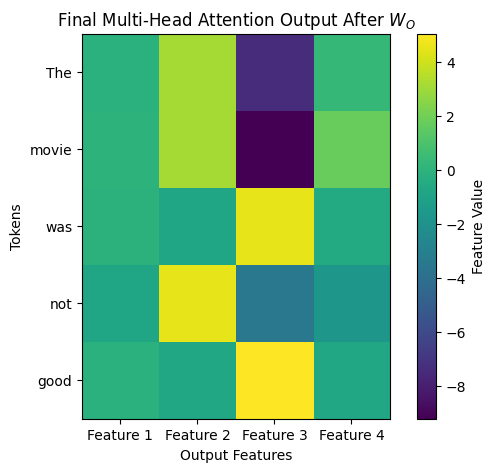

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -------------------------------
# Helper functions
# -------------------------------

def row_softmax(matrix):
    matrix = matrix - np.max(matrix, axis=1, keepdims=True)
    exp_matrix = np.exp(matrix)
    return exp_matrix / np.sum(exp_matrix, axis=1, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T
    scaled_scores = scores / np.sqrt(d_k)
    attention_weights = row_softmax(scaled_scores)
    output = attention_weights @ V
    return scores, scaled_scores, attention_weights, output


# -------------------------------
# Toy sentence and shape setup
# -------------------------------

tokens = ["The", "movie", "was", "not", "good"]

n = 5
d_model = 4
h = 2
d_k = d_model // h

X = np.random.randn(n, d_model)

print("Tokens:")
print(tokens)

print("\nShape setup:")
print("X shape:", X.shape)
print("n:", n)
print("d_model:", d_model)
print("h:", h)
print("d_k:", d_k)


# -------------------------------
# Projection matrices for each head
# -------------------------------

W_Q = []
W_K = []
W_V = []

for head_index in range(h):
    W_Q.append(np.random.randn(d_model, d_k))
    W_K.append(np.random.randn(d_model, d_k))
    W_V.append(np.random.randn(d_model, d_k))


# -------------------------------
# Compute each head output
# -------------------------------

head_outputs = []
attention_matrices = []

for head_index in range(h):
    Q = X @ W_Q[head_index]
    K = X @ W_K[head_index]
    V = X @ W_V[head_index]

    scores, scaled_scores, A, head_output = scaled_dot_product_attention(Q, K, V)

    attention_matrices.append(A)
    head_outputs.append(head_output)

    print(f"\n================ Head {head_index + 1} ================")
    print("Q shape:", Q.shape)
    print("K shape:", K.shape)
    print("V shape:", V.shape)
    print("Attention matrix A shape:", A.shape)
    print("Head output shape:", head_output.shape)


# -------------------------------
# Concatenate heads
# -------------------------------

H_concat = np.concatenate(head_outputs, axis=1)

print("\n================ Concatenated Heads ================")
print("H_concat shape:", H_concat.shape)
print("Expected shape:", (n, h * d_k))


# -------------------------------
# Output projection matrix
# -------------------------------

W_O = np.random.randn(h * d_k, d_model)

print("\n================ Output Projection ================")
print("W_O shape:", W_O.shape)


# -------------------------------
# Final multi-head attention output
# -------------------------------

Z_multi_head = H_concat @ W_O

print("\nFinal multi-head attention output shape:")
print(Z_multi_head.shape)

print("\nFinal multi-head attention output Z_multi_head:")
print(Z_multi_head)


# -------------------------------
# Visualize final output representation
# -------------------------------

plt.figure(figsize=(7, 5))
plt.imshow(Z_multi_head)
plt.xticks(range(Z_multi_head.shape[1]), [f"Feature {i+1}" for i in range(Z_multi_head.shape[1])])
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Output Features")
plt.ylabel("Tokens")
plt.title("Final Multi-Head Attention Output After $W_O$")
plt.colorbar(label="Feature Value")
plt.show()

## Observation / Interpretation

Before applying the output projection, the concatenated head matrix had shape:

$$
H_{\text{concat}} \in \mathbb{R}^{5 \times 4}
$$

This matrix contains features from both heads.

However, the features are only placed side by side.

The output projection matrix is:

$$
W_O \in \mathbb{R}^{4 \times 4}
$$

After applying:

$$
Z_{\text{multi-head}} = H_{\text{concat}}W_O
$$

we get:

$$
Z_{\text{multi-head}} \in \mathbb{R}^{5 \times 4}
$$

This final matrix has one contextual vector per token.

Each token is still represented using:

$$
d_{\text{model}} = 4
$$

features.

The role of $W_O$ is important.

It allows the model to learn how to combine features coming from different attention heads.

Without $W_O$, the head outputs are only concatenated.

With $W_O$, information from different heads can interact and be mixed into the final token representation.

## Concept Check

1. What is the shape of the concatenated matrix $H$ in this example?

2. What is the shape of the output projection matrix $W_O$?

3. What is the formula for the final multi-head attention output after output projection?

4. Why is concatenation alone not enough?

5. Why is it useful that the final output shape matches $X$?

## Instructor-Only Answers

1. The concatenated matrix has shape:

$$
H \in \mathbb{R}^{5 \times 4}
$$

because two head outputs of shape:

$$
5 \times 2
$$

are concatenated along the feature dimension.

2. The output projection matrix has shape:

$$
W_O \in \mathbb{R}^{4 \times 4}
$$

In general:

$$
W_O \in \mathbb{R}^{d_{\text{model}} \times d_{\text{model}}}
$$

when:

$$
h d_k = d_{\text{model}}
$$

3. The final output is:

$$
Z = HW_O
$$

4. Concatenation alone is not enough because it only places head outputs side by side.

It does not learn how to combine or mix information from different heads.

The output projection $W_O$ performs this mixing.

5. It is useful that the final output shape matches $X$ because the multi-head attention block can be inserted into a Transformer architecture without changing the expected representation size.

The next component can still receive a matrix of shape:

$$
n \times d_{\text{model}}
$$

## Bridge to Next Section

We have now completed the full computation flow:

1. Start with input embeddings:

$$
X
$$

2. Compute head-specific projections:

$$
Q^{(r)}, K^{(r)}, V^{(r)}
$$

3. Compute attention independently per head:

$$
\text{head}_r
$$

4. Concatenate the head outputs:

$$
H =
\mathrm{Concat}
\left(
\text{head}_1,
\text{head}_2,
\dots,
\text{head}_h
\right)
$$

5. Apply output projection:

$$
Z = HW_O
$$

Now we are ready to write the complete multi-head attention formula in one compact mathematical expression.

## SECTION 10: Full Multi-Head Attention Formula

We have now built multi-head attention step by step.

The complete idea is:

1. Start with the input embedding matrix:

$$
X
$$

2. For each head, create separate projected matrices:

$$
Q^{(r)}, K^{(r)}, V^{(r)}
$$

3. Compute scaled dot-product attention independently for each head.

4. Concatenate all head outputs.

5. Apply the output projection matrix:

$$
W_O
$$

This gives the final multi-head attention output.

Multi-head attention can therefore be understood as:

> multiple parallel self-attention operations followed by concatenation and output projection.

Each head learns a different attention view, and $W_O$ learns how to combine those views.

## Mathematics: Complete Multi-Head Attention Formula

For head $r$, the projected query, key, and value matrices are:

$$
Q^{(r)} = XW_Q^{(r)}
$$

$$
K^{(r)} = XW_K^{(r)}
$$

$$
V^{(r)} = XW_V^{(r)}
$$

The output of head $r$ is:

$$
\text{head}_r
=
\mathrm{Attention}
\left(
Q^{(r)}, K^{(r)}, V^{(r)}
\right)
$$

Using scaled dot-product attention:

$$
\text{head}_r
=
\mathrm{softmax}
\left(
\frac{Q^{(r)}K^{(r)\top}}{\sqrt{d_k}}
\right)
V^{(r)}
$$

Substituting the projections:

$$
\text{head}_r
=
\mathrm{softmax}
\left(
\frac{
XW_Q^{(r)}
\left(XW_K^{(r)}\right)^\top
}
{\sqrt{d_k}}
\right)
XW_V^{(r)}
$$

Now concatenate all heads:

$$
H
=
\mathrm{Concat}
\left(
\text{head}_1,
\text{head}_2,
\dots,
\text{head}_h
\right)
$$

Then apply the output projection:

$$
Z = HW_O
$$

Therefore, the full multi-head attention formula is:

$$
\mathrm{MultiHead}(X)
=
\mathrm{Concat}
\left(
\text{head}_1,
\text{head}_2,
\dots,
\text{head}_h
\right)W_O
$$

where:

$$
\text{head}_r
=
\mathrm{Attention}
\left(
XW_Q^{(r)},
XW_K^{(r)},
XW_V^{(r)}
\right)
$$

Shape summary for our toy example:

$$
X \in \mathbb{R}^{5 \times 4}
$$

$$
W_Q^{(r)}, W_K^{(r)}, W_V^{(r)}
\in
\mathbb{R}^{4 \times 2}
$$

$$
Q^{(r)}, K^{(r)}, V^{(r)}
\in
\mathbb{R}^{5 \times 2}
$$

$$
\text{head}_r \in \mathbb{R}^{5 \times 2}
$$

$$
H \in \mathbb{R}^{5 \times 4}
$$

$$
W_O \in \mathbb{R}^{4 \times 4}
$$

$$
Z \in \mathbb{R}^{5 \times 4}
$$

Tokens:
['The', 'movie', 'was', 'not', 'good']

Input shape:
X: (5, 4)

Shape setup:
n: 5
d_model: 4
h: 2
d_k: 2

Output projection shape:
W_O: (4, 4)

================ Head 1 ================
W_Q shape: (4, 2)
W_K shape: (4, 2)
W_V shape: (4, 2)
Q shape: (5, 2)
K shape: (5, 2)
V shape: (5, 2)
Attention matrix A shape: (5, 5)
Head output shape: (5, 2)

================ Head 2 ================
W_Q shape: (4, 2)
W_K shape: (4, 2)
W_V shape: (4, 2)
Q shape: (5, 2)
K shape: (5, 2)
V shape: (5, 2)
Attention matrix A shape: (5, 5)
Head output shape: (5, 2)

================ Concatenation ================
H_concat shape: (5, 4)

================ Final Output ================
Z_multi_head shape: (5, 4)

Z_multi_head:
[[-0.13745564  3.13561251 -7.39461358  0.29554359]
 [ 0.02077774  3.11960883 -9.2089391   1.74194754]
 [-0.03171858 -0.77017456  4.51527299 -0.52852227]
 [-0.80848888  4.52296789 -3.5156731  -1.66872677]
 [-0.09858339 -0.6997809   5.03338753 -0.6758568 ]]


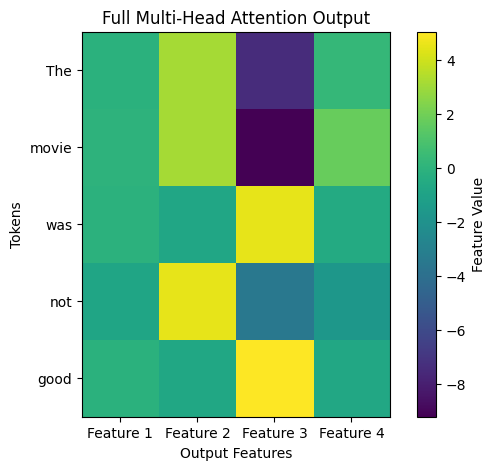

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -------------------------------
# Helper functions
# -------------------------------

def row_softmax(matrix):
    matrix = matrix - np.max(matrix, axis=1, keepdims=True)
    exp_matrix = np.exp(matrix)
    return exp_matrix / np.sum(exp_matrix, axis=1, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T
    scaled_scores = scores / np.sqrt(d_k)
    attention_weights = row_softmax(scaled_scores)
    output = attention_weights @ V
    return scores, scaled_scores, attention_weights, output


# -------------------------------
# Toy sentence and shape setup
# -------------------------------

tokens = ["The", "movie", "was", "not", "good"]

n = 5
d_model = 4
h = 2
d_k = d_model // h

X = np.random.randn(n, d_model)

print("Tokens:")
print(tokens)

print("\nInput shape:")
print("X:", X.shape)

print("\nShape setup:")
print("n:", n)
print("d_model:", d_model)
print("h:", h)
print("d_k:", d_k)


# -------------------------------
# Projection matrices for all heads
# -------------------------------

W_Q = []
W_K = []
W_V = []

for head_index in range(h):
    W_Q.append(np.random.randn(d_model, d_k))
    W_K.append(np.random.randn(d_model, d_k))
    W_V.append(np.random.randn(d_model, d_k))

W_O = np.random.randn(h * d_k, d_model)

print("\nOutput projection shape:")
print("W_O:", W_O.shape)


# -------------------------------
# Compute full multi-head attention
# -------------------------------

head_outputs = []
attention_matrices = []

for head_index in range(h):
    Q = X @ W_Q[head_index]
    K = X @ W_K[head_index]
    V = X @ W_V[head_index]

    scores, scaled_scores, A, head_output = scaled_dot_product_attention(Q, K, V)

    attention_matrices.append(A)
    head_outputs.append(head_output)

    print(f"\n================ Head {head_index + 1} ================")
    print("W_Q shape:", W_Q[head_index].shape)
    print("W_K shape:", W_K[head_index].shape)
    print("W_V shape:", W_V[head_index].shape)

    print("Q shape:", Q.shape)
    print("K shape:", K.shape)
    print("V shape:", V.shape)

    print("Attention matrix A shape:", A.shape)
    print("Head output shape:", head_output.shape)


# -------------------------------
# Concatenate all heads
# -------------------------------

H_concat = np.concatenate(head_outputs, axis=1)

print("\n================ Concatenation ================")
print("H_concat shape:", H_concat.shape)


# -------------------------------
# Apply output projection
# -------------------------------

Z_multi_head = H_concat @ W_O

print("\n================ Final Output ================")
print("Z_multi_head shape:", Z_multi_head.shape)

print("\nZ_multi_head:")
print(Z_multi_head)


# -------------------------------
# Visualize final output
# -------------------------------

plt.figure(figsize=(7, 5))
plt.imshow(Z_multi_head)
plt.xticks(range(Z_multi_head.shape[1]), [f"Feature {i+1}" for i in range(Z_multi_head.shape[1])])
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Output Features")
plt.ylabel("Tokens")
plt.title("Full Multi-Head Attention Output")
plt.colorbar(label="Feature Value")
plt.show()

## Concept Check

1. Write the formula for $\text{head}_r$ using $Q^{(r)}, K^{(r)}, V^{(r)}$.

2. Write the formula for $\text{head}_r$ directly in terms of $X$ and the projection matrices.

3. What is the formula for $\mathrm{MultiHead}(X)$?

4. Why do we concatenate the heads before applying $W_O$?

5. What is the final output shape of multi-head attention in this example?

## Instructor-Only Answers

1. The output of head $r$ is:

$$
\text{head}_r
=
\mathrm{softmax}
\left(
\frac{Q^{(r)}K^{(r)\top}}{\sqrt{d_k}}
\right)
V^{(r)}
$$

2. Directly in terms of $X$:

$$
\text{head}_r
=
\mathrm{softmax}
\left(
\frac{
XW_Q^{(r)}
\left(XW_K^{(r)}\right)^\top
}
{\sqrt{d_k}}
\right)
XW_V^{(r)}
$$

3. Multi-head attention is:

$$
\mathrm{MultiHead}(X)
=
\mathrm{Concat}
\left(
\text{head}_1,
\text{head}_2,
\dots,
\text{head}_h
\right)W_O
$$

where:

$$
\text{head}_r
=
\mathrm{Attention}
\left(
XW_Q^{(r)},
XW_K^{(r)},
XW_V^{(r)}
\right)
$$

4. We concatenate the heads because each head produces a different contextual representation.

Concatenation collects all head-specific representations into one matrix before $W_O$ mixes them.

5. The final output shape is:

$$
Z_{\text{multi-head}} \in \mathbb{R}^{5 \times 4}
$$

This matches the shape of the input matrix:

$$
X \in \mathbb{R}^{5 \times 4}
$$

## Bridge to Next Section

We now have the complete formula for multi-head attention:

$$
\mathrm{MultiHead}(X)
=
\mathrm{Concat}
\left(
\text{head}_1,
\text{head}_2,
\dots,
\text{head}_h
\right)W_O
$$

Now that the complete mechanism is clear, we should compare it directly with single-head attention.

This comparison will help us understand what multi-head attention adds beyond the original self-attention mechanism.

## SECTION 11: Single-Head vs Multi-Head Attention

Now that we have derived the complete multi-head attention formula, we compare it with single-head attention.

Single-head attention computes one attention pattern.

It produces one attention matrix:

$$
A \in \mathbb{R}^{n \times n}
$$

This means each token gets one learned view of how it should attend to the other tokens.

Multi-head attention computes multiple attention patterns in parallel.

For $h$ heads, it produces:

$$
A^{(1)}, A^{(2)}, \dots, A^{(h)}
$$

Each head has its own projection matrices:

$$
W_Q^{(r)}, W_K^{(r)}, W_V^{(r)}
$$

So each head can learn a different token relationship pattern.

Single-head attention asks:

> “What is one useful attention pattern for this sentence?”

Multi-head attention asks:

> “What are multiple useful attention patterns for this sentence?”

This is the major representational advantage of multi-head attention.

## Mathematics: Comparing Single-Head and Multi-Head Attention

For single-head attention:

$$
Q = XW_Q
$$

$$
K = XW_K
$$

$$
V = XW_V
$$

and:

$$
Z_{\text{single}}
=
\mathrm{softmax}
\left(
\frac{QK^\top}{\sqrt{d_k}}
\right)V
$$

This gives one attention output:

$$
Z_{\text{single}} \in \mathbb{R}^{n \times d_k}
$$

In our toy setup:

$$
Z_{\text{single}} \in \mathbb{R}^{5 \times 2}
$$

For multi-head attention, each head computes:

$$
\text{head}_r
=
\mathrm{softmax}
\left(
\frac{Q^{(r)}K^{(r)\top}}{\sqrt{d_k}}
\right)V^{(r)}
$$

where:

$$
Q^{(r)} = XW_Q^{(r)}
$$

$$
K^{(r)} = XW_K^{(r)}
$$

$$
V^{(r)} = XW_V^{(r)}
$$

Then:

$$
H =
\mathrm{Concat}
\left(
\text{head}_1,
\text{head}_2,
\dots,
\text{head}_h
\right)
$$

and:

$$
Z_{\text{multi}}
=
HW_O
$$

So:

$$
Z_{\text{multi}}
=
\mathrm{Concat}
\left(
\text{head}_1,
\text{head}_2,
\dots,
\text{head}_h
\right)W_O
$$

In our toy setup:

$$
\text{head}_1 \in \mathbb{R}^{5 \times 2}
$$

$$
\text{head}_2 \in \mathbb{R}^{5 \times 2}
$$

$$
H \in \mathbb{R}^{5 \times 4}
$$

$$
W_O \in \mathbb{R}^{4 \times 4}
$$

Therefore:

$$
Z_{\text{multi}} \in \mathbb{R}^{5 \times 4}
$$

The key difference is:

Single-head attention gives one attention view.

Multi-head attention gives multiple attention views and then combines them.

Tokens:
['The', 'movie', 'was', 'not', 'good']

Input shape:
X: (5, 4)

Shape setup:
n: 5
d_model: 4
h: 2
d_k: 2

================ Single-Head Attention ================
W_Q_single shape: (4, 2)
W_K_single shape: (4, 2)
W_V_single shape: (4, 2)

Q_single shape: (5, 2)
K_single shape: (5, 2)
V_single shape: (5, 2)

Single-head attention matrix shape: (5, 5)
Single-head output shape: (5, 2)

================ Multi-Head Attention ================

Head 1
Q shape: (5, 2)
K shape: (5, 2)
V shape: (5, 2)
Attention matrix shape: (5, 5)
Head output shape: (5, 2)

Head 2
Q shape: (5, 2)
K shape: (5, 2)
V shape: (5, 2)
Attention matrix shape: (5, 5)
Head output shape: (5, 2)

Concatenated head output shape: (5, 4)
W_O shape: (4, 4)
Multi-head final output shape: (5, 4)


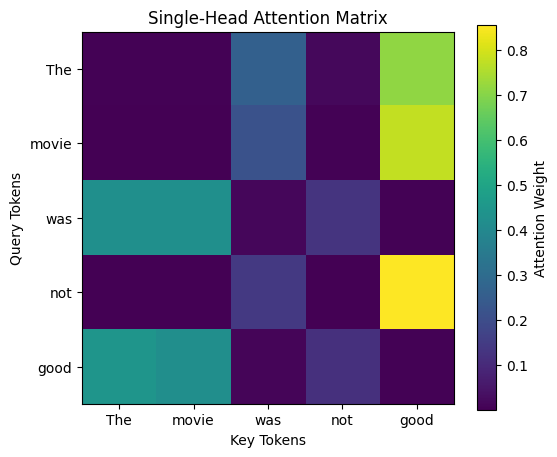

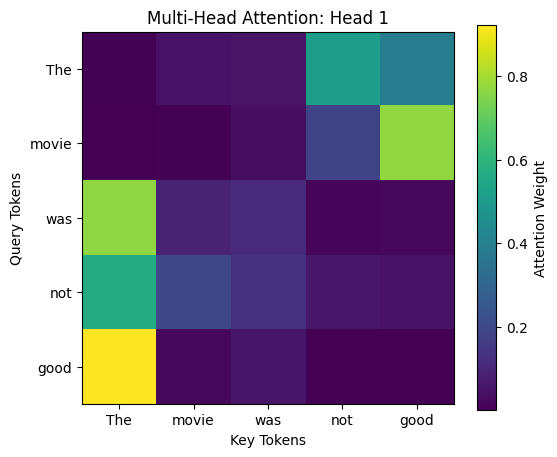

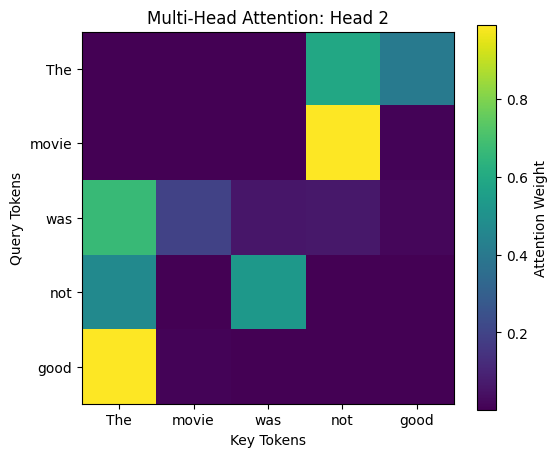

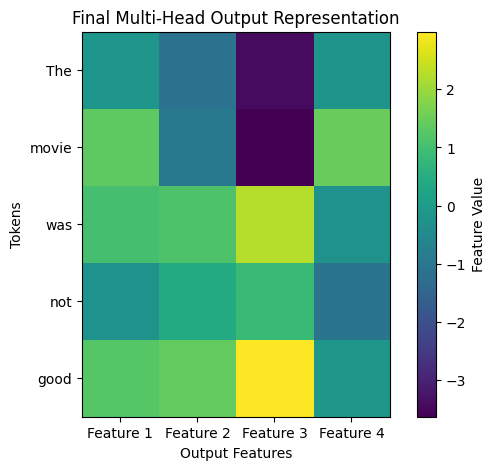

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -------------------------------
# Helper functions
# -------------------------------

def row_softmax(matrix):
    matrix = matrix - np.max(matrix, axis=1, keepdims=True)
    exp_matrix = np.exp(matrix)
    return exp_matrix / np.sum(exp_matrix, axis=1, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T
    scaled_scores = scores / np.sqrt(d_k)
    attention_weights = row_softmax(scaled_scores)
    output = attention_weights @ V
    return scores, scaled_scores, attention_weights, output


# -------------------------------
# Toy sentence and shape setup
# -------------------------------

tokens = ["The", "movie", "was", "not", "good"]

n = 5
d_model = 4
h = 2
d_k = d_model // h

X = np.random.randn(n, d_model)

print("Tokens:")
print(tokens)

print("\nInput shape:")
print("X:", X.shape)

print("\nShape setup:")
print("n:", n)
print("d_model:", d_model)
print("h:", h)
print("d_k:", d_k)


# =====================================================
# Single-head attention
# =====================================================

print("\n================ Single-Head Attention ================")

W_Q_single = np.random.randn(d_model, d_k)
W_K_single = np.random.randn(d_model, d_k)
W_V_single = np.random.randn(d_model, d_k)

Q_single = X @ W_Q_single
K_single = X @ W_K_single
V_single = X @ W_V_single

scores_single, scaled_scores_single, A_single, Z_single = scaled_dot_product_attention(
    Q_single,
    K_single,
    V_single
)

print("W_Q_single shape:", W_Q_single.shape)
print("W_K_single shape:", W_K_single.shape)
print("W_V_single shape:", W_V_single.shape)

print("\nQ_single shape:", Q_single.shape)
print("K_single shape:", K_single.shape)
print("V_single shape:", V_single.shape)

print("\nSingle-head attention matrix shape:", A_single.shape)
print("Single-head output shape:", Z_single.shape)


# =====================================================
# Multi-head attention
# =====================================================

print("\n================ Multi-Head Attention ================")

W_Q_heads = []
W_K_heads = []
W_V_heads = []

for head_index in range(h):
    W_Q_heads.append(np.random.randn(d_model, d_k))
    W_K_heads.append(np.random.randn(d_model, d_k))
    W_V_heads.append(np.random.randn(d_model, d_k))

W_O = np.random.randn(h * d_k, d_model)

head_outputs = []
attention_matrices = []

for head_index in range(h):
    Q = X @ W_Q_heads[head_index]
    K = X @ W_K_heads[head_index]
    V = X @ W_V_heads[head_index]

    scores, scaled_scores, A, head_output = scaled_dot_product_attention(Q, K, V)

    attention_matrices.append(A)
    head_outputs.append(head_output)

    print(f"\nHead {head_index + 1}")
    print("Q shape:", Q.shape)
    print("K shape:", K.shape)
    print("V shape:", V.shape)
    print("Attention matrix shape:", A.shape)
    print("Head output shape:", head_output.shape)

H_concat = np.concatenate(head_outputs, axis=1)
Z_multi = H_concat @ W_O

print("\nConcatenated head output shape:", H_concat.shape)
print("W_O shape:", W_O.shape)
print("Multi-head final output shape:", Z_multi.shape)


# =====================================================
# Visual comparison
# =====================================================

plt.figure(figsize=(6, 5))
plt.imshow(A_single)
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("Single-Head Attention Matrix")
plt.colorbar(label="Attention Weight")
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(attention_matrices[0])
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("Multi-Head Attention: Head 1")
plt.colorbar(label="Attention Weight")
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(attention_matrices[1])
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("Multi-Head Attention: Head 2")
plt.colorbar(label="Attention Weight")
plt.show()

plt.figure(figsize=(7, 5))
plt.imshow(Z_multi)
plt.xticks(range(Z_multi.shape[1]), [f"Feature {i+1}" for i in range(Z_multi.shape[1])])
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Output Features")
plt.ylabel("Tokens")
plt.title("Final Multi-Head Output Representation")
plt.colorbar(label="Feature Value")
plt.show()

## Observation / Interpretation

Single-head attention produced one attention matrix:

$$
A_{\text{single}} \in \mathbb{R}^{5 \times 5}
$$

and one output:

$$
Z_{\text{single}} \in \mathbb{R}^{5 \times 2}
$$

In contrast, multi-head attention produced two attention matrices:

$$
A^{(1)} \in \mathbb{R}^{5 \times 5}
$$

$$
A^{(2)} \in \mathbb{R}^{5 \times 5}
$$

Each head output had shape:

$$
\text{head}_r \in \mathbb{R}^{5 \times 2}
$$

After concatenation:

$$
H_{\text{concat}} \in \mathbb{R}^{5 \times 4}
$$

After output projection:

$$
Z_{\text{multi}} \in \mathbb{R}^{5 \times 4}
$$

The important difference is not only the final shape.

The important difference is that multi-head attention creates multiple attention matrices.

Each attention matrix can represent a different token relationship pattern.

This makes multi-head attention more expressive than single-head attention.

## Concept Check

1. How many attention matrices does single-head attention produce?

2. How many attention matrices does multi-head attention produce when $h = 2$?

3. Why can different heads learn different attention patterns?

4. What is the main representational advantage of multi-head attention?

5. Why do we apply $W_O$ after concatenating the heads?

## Instructor-Only Answers

1. Single-head attention produces one attention matrix:

$$
A_{\text{single}} \in \mathbb{R}^{n \times n}
$$

2. When:

$$
h = 2
$$

multi-head attention produces two attention matrices:

$$
A^{(1)}
$$

and:

$$
A^{(2)}
$$

Each has shape:

$$
5 \times 5
$$

in this example.

3. Different heads can learn different attention patterns because each head has its own projection matrices:

$$
W_Q^{(r)}, W_K^{(r)}, W_V^{(r)}
$$

So each head computes attention in a different representation space.

4. The main representational advantage is that multi-head attention can capture multiple relationships in parallel.

For example, one head may focus on negation, another on phrase structure, and another on semantic dependency.

5. We apply $W_O$ after concatenating the heads because concatenation only places head outputs side by side.

The output projection $W_O$ learns how to mix and combine information from different heads into a final representation.

## SECTION 12: NumPy Function for Multi-Head Attention

So far, we computed multi-head attention step by step.

Now we will package the full computation into a clean NumPy function.

This is important because in real implementations, multi-head attention is not written manually for every head.

Instead, we define a reusable function that performs the full flow:

1. Receive input matrix $X$
2. Compute $Q$, $K$, and $V$ for each head
3. Compute scaled dot-product attention per head
4. Concatenate all head outputs
5. Apply the output projection matrix $W_O$
6. Return the final multi-head attention output

The goal of this section is not to build a production Transformer layer.

The goal is to write a clean educational implementation where every shape is visible and interpretable.

## Mathematics: Functional Form of Multi-Head Attention

For each head $r$, we compute:

$$
Q^{(r)} = XW_Q^{(r)}
$$

$$
K^{(r)} = XW_K^{(r)}
$$

$$
V^{(r)} = XW_V^{(r)}
$$

Then:

$$
\text{head}_r
=
\mathrm{softmax}
\left(
\frac{Q^{(r)}K^{(r)\top}}{\sqrt{d_k}}
\right)
V^{(r)}
$$

After computing all heads:

$$
H =
\mathrm{Concat}
\left(
\text{head}_1,
\text{head}_2,
\dots,
\text{head}_h
\right)
$$

Finally:

$$
Z_{\text{multi}}
=
HW_O
$$

So the function should implement:

$$
\mathrm{MultiHead}(X)
=
\mathrm{Concat}
\left(
\text{head}_1,
\text{head}_2,
\dots,
\text{head}_h
\right)W_O
$$

where:

$$
\text{head}_r
=
\mathrm{Attention}
\left(
XW_Q^{(r)},
XW_K^{(r)},
XW_V^{(r)}
\right)
$$

In our toy setup:

$$
X \in \mathbb{R}^{5 \times 4}
$$

$$
h = 2
$$

$$
d_k = 2
$$

$$
W_O \in \mathbb{R}^{4 \times 4}
$$

and:

$$
Z_{\text{multi}} \in \mathbb{R}^{5 \times 4}
$$

Tokens:
['The', 'movie', 'was', 'not', 'good']

Shape setup:
n: 5
d_model: 4
h: 2
d_k: 2
Input X shape: (5, 4)
Number of heads: 2

================ Head 1 ================
W_Q shape: (4, 2)
W_K shape: (4, 2)
W_V shape: (4, 2)
Q shape: (5, 2)
K shape: (5, 2)
V shape: (5, 2)
Attention score matrix shape: (5, 5)
Attention weight matrix shape: (5, 5)
Head output shape: (5, 2)

================ Head 2 ================
W_Q shape: (4, 2)
W_K shape: (4, 2)
W_V shape: (4, 2)
Q shape: (5, 2)
K shape: (5, 2)
V shape: (5, 2)
Attention score matrix shape: (5, 5)
Attention weight matrix shape: (5, 5)
Head output shape: (5, 2)

================ Concatenation ================
H_concat shape: (5, 4)

================ Output Projection ================
W_O shape: (4, 4)
Final multi-head output shape: (5, 4)

Final output Z_multi:
[[-0.13745564  3.13561251 -7.39461358  0.29554359]
 [ 0.02077774  3.11960883 -9.2089391   1.74194754]
 [-0.03171858 -0.77017456  4.51527299 -0.52852227]
 [-0.80848888  4.522967

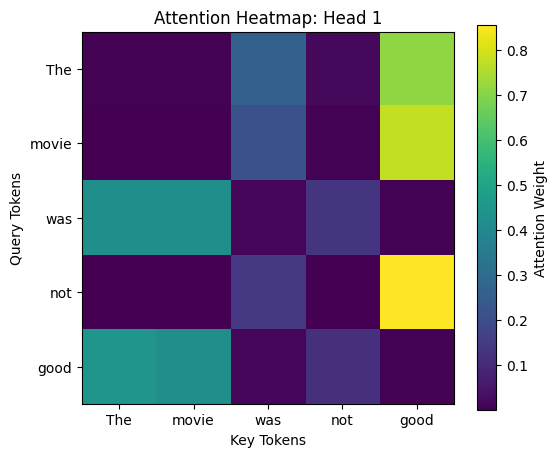

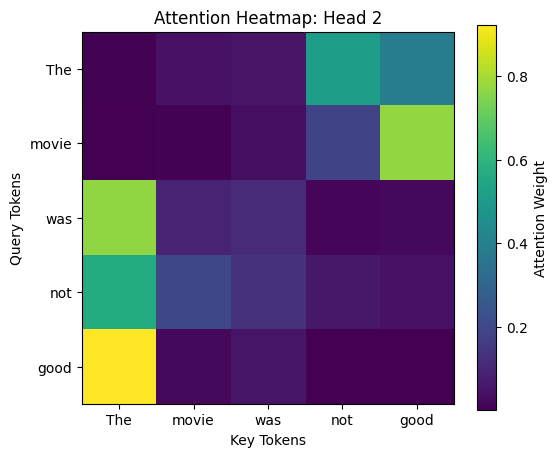

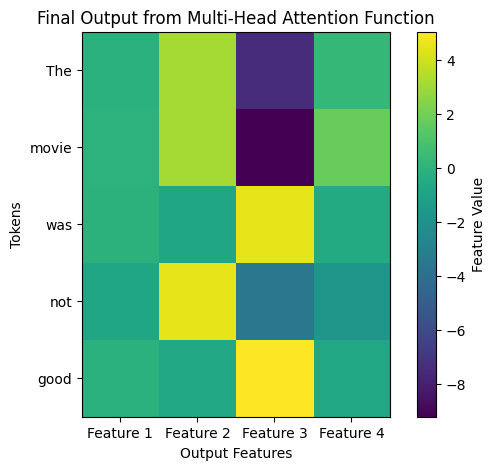

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -------------------------------
# Helper functions
# -------------------------------

def row_softmax(matrix):
    matrix = matrix - np.max(matrix, axis=1, keepdims=True)
    exp_matrix = np.exp(matrix)
    return exp_matrix / np.sum(exp_matrix, axis=1, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T
    scaled_scores = scores / np.sqrt(d_k)
    attention_weights = row_softmax(scaled_scores)
    output = attention_weights @ V
    return scores, scaled_scores, attention_weights, output


# -------------------------------
# Multi-head attention function
# -------------------------------

def multi_head_attention(X, W_Q_list, W_K_list, W_V_list, W_O):
    """
    Educational NumPy implementation of multi-head attention.

    Parameters
    ----------
    X : np.ndarray
        Input matrix of shape (n, d_model)

    W_Q_list, W_K_list, W_V_list : list of np.ndarray
        Projection matrices for each head.
        Each matrix has shape (d_model, d_k)

    W_O : np.ndarray
        Output projection matrix of shape (h * d_k, d_model)

    Returns
    -------
    Z_multi : np.ndarray
        Final multi-head attention output of shape (n, d_model)

    attention_matrices : list of np.ndarray
        Attention matrix for each head, each of shape (n, n)

    head_outputs : list of np.ndarray
        Output of each attention head, each of shape (n, d_k)

    H_concat : np.ndarray
        Concatenated head output of shape (n, h * d_k)
    """

    h = len(W_Q_list)

    attention_matrices = []
    head_outputs = []

    print("Input X shape:", X.shape)
    print("Number of heads:", h)

    for head_index in range(h):
        print(f"\n================ Head {head_index + 1} ================")

        W_Q = W_Q_list[head_index]
        W_K = W_K_list[head_index]
        W_V = W_V_list[head_index]

        print("W_Q shape:", W_Q.shape)
        print("W_K shape:", W_K.shape)
        print("W_V shape:", W_V.shape)

        Q = X @ W_Q
        K = X @ W_K
        V = X @ W_V

        print("Q shape:", Q.shape)
        print("K shape:", K.shape)
        print("V shape:", V.shape)

        scores, scaled_scores, A, head_output = scaled_dot_product_attention(Q, K, V)

        print("Attention score matrix shape:", scores.shape)
        print("Attention weight matrix shape:", A.shape)
        print("Head output shape:", head_output.shape)

        attention_matrices.append(A)
        head_outputs.append(head_output)

    H_concat = np.concatenate(head_outputs, axis=1)

    print("\n================ Concatenation ================")
    print("H_concat shape:", H_concat.shape)

    print("\n================ Output Projection ================")
    print("W_O shape:", W_O.shape)

    Z_multi = H_concat @ W_O

    print("Final multi-head output shape:", Z_multi.shape)

    return Z_multi, attention_matrices, head_outputs, H_concat


# -------------------------------
# Toy sentence and setup
# -------------------------------

tokens = ["The", "movie", "was", "not", "good"]

n = 5
d_model = 4
h = 2
d_k = d_model // h

X = np.random.randn(n, d_model)

print("Tokens:")
print(tokens)

print("\nShape setup:")
print("n:", n)
print("d_model:", d_model)
print("h:", h)
print("d_k:", d_k)


# -------------------------------
# Create projection matrices
# -------------------------------

W_Q_list = []
W_K_list = []
W_V_list = []

for head_index in range(h):
    W_Q_list.append(np.random.randn(d_model, d_k))
    W_K_list.append(np.random.randn(d_model, d_k))
    W_V_list.append(np.random.randn(d_model, d_k))

W_O = np.random.randn(h * d_k, d_model)


# -------------------------------
# Run multi-head attention
# -------------------------------

Z_multi, attention_matrices, head_outputs, H_concat = multi_head_attention(
    X,
    W_Q_list,
    W_K_list,
    W_V_list,
    W_O
)

print("\nFinal output Z_multi:")
print(Z_multi)


# -------------------------------
# Visualize attention heads
# -------------------------------

for head_index, A in enumerate(attention_matrices):
    plt.figure(figsize=(6, 5))
    plt.imshow(A)
    plt.xticks(range(len(tokens)), tokens)
    plt.yticks(range(len(tokens)), tokens)
    plt.xlabel("Key Tokens")
    plt.ylabel("Query Tokens")
    plt.title(f"Attention Heatmap: Head {head_index + 1}")
    plt.colorbar(label="Attention Weight")
    plt.show()


# -------------------------------
# Visualize final output
# -------------------------------

plt.figure(figsize=(7, 5))
plt.imshow(Z_multi)
plt.xticks(range(Z_multi.shape[1]), [f"Feature {i+1}" for i in range(Z_multi.shape[1])])
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Output Features")
plt.ylabel("Tokens")
plt.title("Final Output from Multi-Head Attention Function")
plt.colorbar(label="Feature Value")
plt.show()

## Observation / Interpretation

The function `multi_head_attention()` performs the complete multi-head attention pipeline.

It starts with:

$$
X \in \mathbb{R}^{5 \times 4}
$$

For each head, it computes:

$$
Q^{(r)}, K^{(r)}, V^{(r)} \in \mathbb{R}^{5 \times 2}
$$

Each head then produces an attention matrix:

$$
A^{(r)} \in \mathbb{R}^{5 \times 5}
$$

and a head output:

$$
\text{head}_r \in \mathbb{R}^{5 \times 2}
$$

The head outputs are concatenated:

$$
H_{\text{concat}} \in \mathbb{R}^{5 \times 4}
$$

Then the output projection gives:

$$
Z_{\text{multi}} \in \mathbb{R}^{5 \times 4}
$$

The function returns four useful objects:

1. the final multi-head output,
2. the attention matrices,
3. the individual head outputs,
4. the concatenated representation before $W_O$.

This makes the function useful for teaching because students can inspect every intermediate stage.

## Concept Check

1. Why is it useful to package multi-head attention into a function?

2. What are the inputs required by the `multi_head_attention()` function?

3. Why does the function return attention matrices separately?

4. What is the shape of `H_concat` in this example?

5. What is the final output shape returned by the function?

## Instructor-Only Answers

1. It is useful to package multi-head attention into a function because the same sequence of operations must be repeated every time we compute multi-head attention.

A function makes the implementation clean, reusable, and easier to debug.

2. The function requires:

- input matrix $X$,
- list of query projection matrices,
- list of key projection matrices,
- list of value projection matrices,
- output projection matrix $W_O$.

3. The function returns attention matrices separately so that we can visualize and inspect what each head is doing.

This is especially useful for teaching and debugging.

4. In this example:

$$
H_{\text{concat}} \in \mathbb{R}^{5 \times 4}
$$

because we concatenate two head outputs:

$$
5 \times 2
$$

and:

$$
5 \times 2
$$

along the feature dimension.

5. The final output shape is:

$$
Z_{\text{multi}} \in \mathbb{R}^{5 \times 4}
$$

This matches the original input shape:

$$
X \in \mathbb{R}^{5 \times 4}
$$

## SECTION 13: Transformer Encoder Block View

So far, we have implemented multi-head attention.

But in the Transformer, multi-head attention does not exist alone.

It is one major component inside the Transformer Encoder block.

A simplified Transformer Encoder block contains:

1. Multi-Head Self-Attention
2. Residual Connection
3. Layer Normalization
4. Feed-Forward Network
5. Residual Connection
6. Layer Normalization

The flow is:

$$
X
\rightarrow
\text{Multi-Head Attention}
\rightarrow
\text{Add \& Norm}
\rightarrow
\text{Feed-Forward Network}
\rightarrow
\text{Add \& Norm}
\rightarrow
\text{Encoder Output}
$$

Today, our main focus was multi-head attention.

So we will not go deep into layer normalization or feed-forward networks now.

But we must understand where multi-head attention fits in the full encoder block.

The key idea is:

Multi-head attention updates each token using information from all other tokens.

Then the remaining encoder block stabilizes, transforms, and refines those token representations.

## Mathematics: Encoder Block as a Shape-Preserving Transformation

Let the input to the Transformer Encoder block be:

$$
X \in \mathbb{R}^{n \times d_{\text{model}}}
$$

For our toy setup:

$$
X \in \mathbb{R}^{5 \times 4}
$$

Multi-head attention produces:

$$
Z_{\text{MHA}}
=
\mathrm{MultiHead}(X)
$$

where:

$$
Z_{\text{MHA}} \in \mathbb{R}^{n \times d_{\text{model}}}
$$

Then the first residual connection adds the original input back:

$$
U = X + Z_{\text{MHA}}
$$

Shape-wise:

$$
X \in \mathbb{R}^{5 \times 4}
$$

$$
Z_{\text{MHA}} \in \mathbb{R}^{5 \times 4}
$$

Therefore:

$$
U \in \mathbb{R}^{5 \times 4}
$$

Then layer normalization is applied:

$$
\tilde{U} = \mathrm{LayerNorm}(U)
$$

After this, a feed-forward network is applied independently to each token:

$$
F = \mathrm{FFN}(\tilde{U})
$$

where:

$$
F \in \mathbb{R}^{n \times d_{\text{model}}}
$$

Then another residual connection is applied:

$$
Y = \mathrm{LayerNorm}(\tilde{U} + F)
$$

So the full encoder block can be summarized as:

$$
Z_{\text{MHA}} = \mathrm{MultiHead}(X)
$$

$$
\tilde{U} = \mathrm{LayerNorm}(X + Z_{\text{MHA}})
$$

$$
Y = \mathrm{LayerNorm}(\tilde{U} + \mathrm{FFN}(\tilde{U}))
$$

The final encoder output is:

$$
Y \in \mathbb{R}^{n \times d_{\text{model}}}
$$

So the Transformer Encoder block preserves the shape:

$$
\mathbb{R}^{n \times d_{\text{model}}}
\rightarrow
\mathbb{R}^{n \times d_{\text{model}}}
$$

Tokens:
['The', 'movie', 'was', 'not', 'good']

Input X shape: (5, 4)
n: 5
d_model: 4
h: 2
d_k: 2
d_ff: 8

MHA parameter shapes:
Each W_Q, W_K, W_V: (4, 2)
W_O: (4, 4)

FFN parameter shapes:
W_1: (4, 8)
b_1: (8,)
W_2: (8, 4)
b_2: (4,)

================ Step 1: Multi-Head Attention ================
Input X shape: (5, 4)
Z_mha shape: (5, 4)

================ Step 2: Add & Norm ================
X shape: (5, 4)
Z_mha shape: (5, 4)
U = X + Z_mha shape: (5, 4)
U_norm shape: (5, 4)

================ Step 3: Feed-Forward Network ================
U_norm shape: (5, 4)
FFN output F shape: (5, 4)

================ Step 4: Final Add & Norm ================
U_norm shape: (5, 4)
F shape: (5, 4)
Final encoder output Y shape: (5, 4)


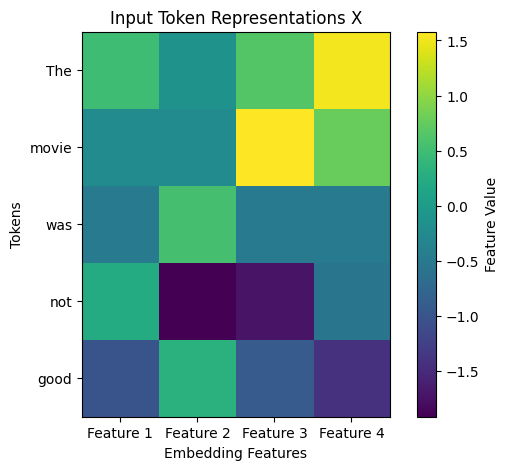

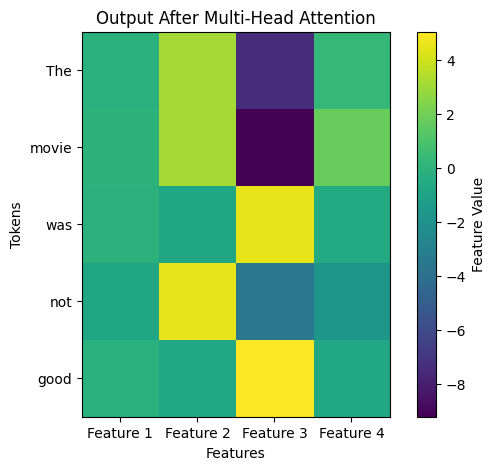

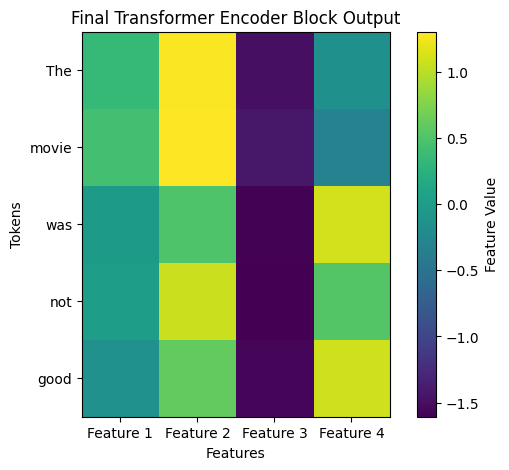

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -------------------------------
# Helper functions
# -------------------------------

def row_softmax(matrix):
    matrix = matrix - np.max(matrix, axis=1, keepdims=True)
    exp_matrix = np.exp(matrix)
    return exp_matrix / np.sum(exp_matrix, axis=1, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T
    scaled_scores = scores / np.sqrt(d_k)
    attention_weights = row_softmax(scaled_scores)
    output = attention_weights @ V
    return scores, scaled_scores, attention_weights, output

def multi_head_attention(X, W_Q_list, W_K_list, W_V_list, W_O):
    h = len(W_Q_list)

    attention_matrices = []
    head_outputs = []

    for head_index in range(h):
        Q = X @ W_Q_list[head_index]
        K = X @ W_K_list[head_index]
        V = X @ W_V_list[head_index]

        scores, scaled_scores, A, head_output = scaled_dot_product_attention(Q, K, V)

        attention_matrices.append(A)
        head_outputs.append(head_output)

    H_concat = np.concatenate(head_outputs, axis=1)
    Z_multi = H_concat @ W_O

    return Z_multi, attention_matrices, head_outputs, H_concat

def simple_layer_norm(X, epsilon=1e-6):
    mean = np.mean(X, axis=1, keepdims=True)
    variance = np.var(X, axis=1, keepdims=True)
    return (X - mean) / np.sqrt(variance + epsilon)

def simple_ffn(X, W_1, b_1, W_2, b_2):
    hidden = X @ W_1 + b_1
    hidden_relu = np.maximum(0, hidden)
    output = hidden_relu @ W_2 + b_2
    return output


# -------------------------------
# Toy sentence and setup
# -------------------------------

tokens = ["The", "movie", "was", "not", "good"]

n = 5
d_model = 4
h = 2
d_k = d_model // h
d_ff = 8

X = np.random.randn(n, d_model)

print("Tokens:")
print(tokens)

print("\nInput X shape:", X.shape)
print("n:", n)
print("d_model:", d_model)
print("h:", h)
print("d_k:", d_k)
print("d_ff:", d_ff)


# -------------------------------
# Multi-head attention parameters
# -------------------------------

W_Q_list = []
W_K_list = []
W_V_list = []

for head_index in range(h):
    W_Q_list.append(np.random.randn(d_model, d_k))
    W_K_list.append(np.random.randn(d_model, d_k))
    W_V_list.append(np.random.randn(d_model, d_k))

W_O = np.random.randn(h * d_k, d_model)

print("\nMHA parameter shapes:")
print("Each W_Q, W_K, W_V:", W_Q_list[0].shape)
print("W_O:", W_O.shape)


# -------------------------------
# Feed-forward network parameters
# -------------------------------

W_1 = np.random.randn(d_model, d_ff)
b_1 = np.random.randn(d_ff)

W_2 = np.random.randn(d_ff, d_model)
b_2 = np.random.randn(d_model)

print("\nFFN parameter shapes:")
print("W_1:", W_1.shape)
print("b_1:", b_1.shape)
print("W_2:", W_2.shape)
print("b_2:", b_2.shape)


# -------------------------------
# Step 1: Multi-head attention
# -------------------------------

Z_mha, attention_matrices, head_outputs, H_concat = multi_head_attention(
    X,
    W_Q_list,
    W_K_list,
    W_V_list,
    W_O
)

print("\n================ Step 1: Multi-Head Attention ================")
print("Input X shape:", X.shape)
print("Z_mha shape:", Z_mha.shape)


# -------------------------------
# Step 2: Residual connection + LayerNorm
# -------------------------------

U = X + Z_mha
U_norm = simple_layer_norm(U)

print("\n================ Step 2: Add & Norm ================")
print("X shape:", X.shape)
print("Z_mha shape:", Z_mha.shape)
print("U = X + Z_mha shape:", U.shape)
print("U_norm shape:", U_norm.shape)


# -------------------------------
# Step 3: Feed-forward network
# -------------------------------

F = simple_ffn(U_norm, W_1, b_1, W_2, b_2)

print("\n================ Step 3: Feed-Forward Network ================")
print("U_norm shape:", U_norm.shape)
print("FFN output F shape:", F.shape)


# -------------------------------
# Step 4: Residual connection + LayerNorm
# -------------------------------

Y = simple_layer_norm(U_norm + F)

print("\n================ Step 4: Final Add & Norm ================")
print("U_norm shape:", U_norm.shape)
print("F shape:", F.shape)
print("Final encoder output Y shape:", Y.shape)


# -------------------------------
# Visualization
# -------------------------------

plt.figure(figsize=(7, 5))
plt.imshow(X)
plt.xticks(range(d_model), [f"Feature {i+1}" for i in range(d_model)])
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Embedding Features")
plt.ylabel("Tokens")
plt.title("Input Token Representations X")
plt.colorbar(label="Feature Value")
plt.show()

plt.figure(figsize=(7, 5))
plt.imshow(Z_mha)
plt.xticks(range(d_model), [f"Feature {i+1}" for i in range(d_model)])
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Features")
plt.ylabel("Tokens")
plt.title("Output After Multi-Head Attention")
plt.colorbar(label="Feature Value")
plt.show()

plt.figure(figsize=(7, 5))
plt.imshow(Y)
plt.xticks(range(d_model), [f"Feature {i+1}" for i in range(d_model)])
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Features")
plt.ylabel("Tokens")
plt.title("Final Transformer Encoder Block Output")
plt.colorbar(label="Feature Value")
plt.show()

## Observation / Interpretation

This section shows where multi-head attention sits inside the Transformer Encoder block.

The input shape is:

$$
X \in \mathbb{R}^{5 \times 4}
$$

After multi-head attention:

$$
Z_{\text{MHA}} \in \mathbb{R}^{5 \times 4}
$$

This is important because the residual connection requires both matrices to have the same shape:

$$
X + Z_{\text{MHA}}
$$

If their shapes did not match, residual addition would not be possible.

After the first Add & Norm step, the shape remains:

$$
5 \times 4
$$

Then the feed-forward network expands and compresses each token representation internally:

$$
4 \rightarrow 8 \rightarrow 4
$$

So the FFN output also returns to:

$$
5 \times 4
$$

Finally, after the second Add & Norm step, the encoder block output is:

$$
Y \in \mathbb{R}^{5 \times 4}
$$

The major point is:

The Transformer Encoder block is shape-preserving.

It changes the meaning and contextual quality of token representations, but it keeps the tensor shape compatible with stacking multiple encoder blocks.

## Bridge to Next Section

We have now connected multi-head attention to the Transformer Encoder block.

This completes the main purpose of today's lecture:

Multi-head attention is not just an isolated formula.

It is the core context-mixing mechanism inside the Transformer Encoder.

The remaining components — residual connections, layer normalization, and feed-forward networks — make the block stable, trainable, and stackable.

In the next lecture, we can go deeper into the Transformer Encoder block as a complete architecture.